# Fine-Tuning di un Componente della Pipeline Agentica

## 1. Problem Definition

Nel nostro sistema Agentic AI (Food Blogger Copilot), il nodo di ricerca (Research Node) ha il compito
cruciale di decodificare il testo non strutturato di una ricetta per estrarre in modo deterministico le
"Sottoricette" complesse (es. identificare preparazioni autonome che subiscono trasformazioni fisiche o
termiche come "Besciamella" o "Mousse al cioccolato", escludendo ingredienti grezzi o prodotti finiti).

Affidare questo specifico compito di *Information Extraction* tramite Prompt Engineering a modelli
generalisti genera un elevato consumo di token e una pericolosa instabilità strutturale. Questo
componente della pipeline riceve come input il testo grezzo della ricetta e deve produrre in output
**esclusivamente un array JSON pulito** contenente le sottoricette individuate. Il blocco a valle
(Neo4j / ChromaDB Router) riutilizza questo array per orchestrare in modo adattivo il GraphRAG e il
Vector RAG, minimizzando le chiamate a sorgenti esterne in caso di ricette già validate.

## 2. Baseline

La Baseline di riferimento è rappresentata dal modello pre-addestrato `meta-llama/Llama-3.2-1B-Instruct`
utilizzato in modalità **Zero-Shot** con lo stesso identico System Prompt impiegato dal modello
specializzato. Attraverso il context manager di PEFT (`model.disable_adapter()`), la baseline viene
spenta ed eseguita direttamente sullo stesso codice di inferenza, per garantire l'assoluta imparzialità
e coerenza del confronto metrico.

## 3. Evaluation Metrics

In coerenza con la natura del task strutturato, la valutazione evita metriche inadatte alla
classificazione (come BLEU o ROUGE) e adotta un insieme completo di metriche ML e di sistema:

- **Format Compliance**: percentuale di risposte che restituiscono un array JSON sintatticamente valido e direttamente parsabile in Python.
- **Precision, Recall e F1-Score (Micro & Macro)**: calcolati confrontando gli elementi estratti con il Ground Truth (Gold Target).
- **Exact Match (Zero Errori)**: percentuale di ricette in cui l'array estratto coincide perfettamente con il target.
- **Tasso di Allucinazione (FDR — False Discovery Rate)**: rapporto tra elementi estratti errati (allucinati) e totale delle estrazioni effettuate (calcolato tramite *fuzzy matching* > 0.8).
- **Metriche di Sistema**: latenza media per query (ms), throughput di generazione (tokens/sec) e picco di memoria VRAM allocata (MB).



In [6]:
# --- CELLA 1: librerie
!pip install -q -U \
    "transformers>=4.45.0" \
    "peft>=0.13.0" \
    "bitsandbytes>=0.43.0" \
    "datasets>=3.0.0" \
    "trl>=0.12.0" \
    "huggingface_hub>=0.26.0" \
    "accelerate>=1.0.0" 2>/dev/null

!pip install --upgrade "torchao>0.16.0" 2>/dev/null

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 79.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 85.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.5 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


### 2. Setup Hardware e Autenticazione (Environment & Security)
L'addestramento di un LLM (anche quantizzato) su un ambiente cloud con risorse limitate come Kaggle (GPU T4 da 16GB) è altamente a rischio di errori di **OOM (Out Of Memory)**. 
Per mitigare questo rischio a livello architetturale, configuriamo l'allocatore di memoria di PyTorch abilitando gli `expandable_segments`. Questo impedisce la frammentazione della VRAM durante i passaggi di forward e backward. 
Inoltre, gestiamo l'autenticazione sicura tramite Kaggle Secrets per ottenere i permessi di scaricamento del modello *gated* Llama-3.2-1B da Hugging Face, evitando di esporre token sensibili nel codice.

In [8]:
# --- CELLA 2: Setup Memoria e Login HuggingFace ---
import os
# Previene la frammentazione della memoria GPU 
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
try:
    secrets = UserSecretsClient()
    login(token=secrets.get_secret("HF_TOKEN"))
    print("✅ Login a Hugging Face effettuato con successo!")
except Exception as e:
    print("❌ Errore login: Assicurati di aver impostato il secret HF_TOKEN su Kaggle.")

✅ Login a Hugging Face effettuato con successo!


### 3. Architettura QLoRA 
Per addestrare un modello da 1.2 Miliardi di parametri come `Llama-3.2-1B-Instruct` senza incorrere in colli di bottiglia computazionali, applichiamo la tecnica **QLoRA** (Quantized Low-Rank Adaptation).
Invece di eseguire un *Full Fine-Tuning* che richiederebbe uno sforzo computazionale non plausibile, Il modello base viene congelato e quantizzato a 4-bit in formato nf4 con doppia quantizzazione attiva, calcolando i gradienti in torch.bfloat16. 



In [10]:
# --- CELLA 3: Import e Caricamento Modello in 4-bit (QLoRA) ---
import torch
import json
import ast
import gc
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig


MODEL_ID = "meta-llama/Llama-3.2-1B-Instruct"
OUTPUT_DIR = "/kaggle/working/llama3_sottoricette"

# Configurazione 4-bit esatta del Notebook 04
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

print("Caricamento Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

print("Caricamento Modello Base (4-bit)...")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,  # L'identificativo esatto del modello da scaricare o caricare (es. "meta-llama/Llama-3.2-1B-Instruct").
    quantization_config=bnb_config,  # Inietta la configurazione BitsAndBytes per caricare i pesi del modello in formato compresso (es. 4-bit). Questo è il cuore del risparmio di VRAM.
    device_map="auto",  # Dice ad Accelerate di distribuire automaticamente e in modo intelligente i vari livelli (layer) del modello sull'hardware disponibile (GPU, e se non basta, RAM/CPU).
    dtype=torch.bfloat16,  # Specifica il formato dei dati (BFloat16) per i calcoli e i layer non quantizzati, garantendo un'ottima stabilità numerica e prestazioni migliori sulle GPU moderne rispetto a FP16 o FP32.
    attn_implementation="sdpa"  # Attiva la "Scaled Dot-Product Attention", un'implementazione nativa di PyTorch (molto simile a FlashAttention) che velocizza drasticamente il calcolo dell'Attention e riduce il consumo di memoria.
)

# Funzione fondamentale della libreria PEFT per abilitare il training su modelli quantizzati (k-bit)
# Questa riga esegue alcune operazioni "sotto il cofano" cruciali per la stabilità: fa il freeze dei pesi originali, converte i layer di normalizzazione (LayerNorm) in float32 per evitare errori di arrotondamento e predispone il modello a calcolare i gradienti solo per gli adattatori LoRA che verranno aggiunti.
model = prepare_model_for_kbit_training(model)

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Caricamento Tokenizer...


config.json:   0%|          | 0.00/877 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/54.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

...

Caricamento Modello Base (4-bit)...


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.47GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

4 & 5. Dataset e Split
----------------------

Il dataset è composto da un totale di **250 esempi** strutturati in formato ChatML. La composizione
include una forte presenza di *Hard Negatives* (ricette prive di sottoricette reali ma contenenti
ingredienti base, etichettate con `[]`) per forzare il modello
ad apprendere la logica discriminativa ed evitare estrazioni coatte da *pattern matching*.

Il dataset è suddiviso rigidamente secondo lo schema classico di hold-out:

- **Train Set**: 200 esempi (80%), utilizzati per l'addestramento della componente.
- **Validation Set**: 25 esempi (10%), dedicati al monitoraggio della loss e alla ricerca iperparametrica.
- **Test Set**: 25 esempi (10%), isolati completamente e utilizzati solo per l'estrazione delle statistiche finali post-addestramento.

In [11]:
# --- CELLA 4: Preparazione Dataset ---
def formatting_prompts_func(examples):
    convos = examples["messages"]
    texts = [tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False) for convo in convos]
    return { "text" : texts }

# Carichiamo i file JSONL con i dati in formato ChatML 
print("Caricamento Dataset...")
train_dataset = load_dataset("json", data_files="/kaggle/input/datasets/arengio/ricette/sottoricette_train.jsonl", split="train")
eval_dataset = load_dataset("json", data_files="/kaggle/input/datasets/arengio/ricette/sottoricette_val.jsonl", split="train")
test_dataset = load_dataset("json", data_files="/kaggle/input/datasets/arengio/ricette/sottoricette_test.jsonl", split="train")

# Applica la funzione 'formatting_prompts_func' a tutti gli elementi del dataset di addestramento.
# Questa funzione prenderà la colonna "messages" (la struttura a chat di Llama) e applicherà il chat_template del tokenizer per unire il tutto in un'unica stringa di testo continua.
# Il parametro 'batched=True' indica alla libreria Datasets di processare gli esempi a blocchi (batch) anziché uno alla volta, velocizzando enormemente l'operazione.
train_dataset = train_dataset.map(formatting_prompts_func, batched=True)

# Esegue esattamente la stessa operazione di conversione e formattazione sul dataset di validazione (eval_dataset).
# È fondamentale che anche i dati di test/validazione siano nello stesso identico formato testuale su cui il modello si sta addestrando.
eval_dataset = eval_dataset.map(formatting_prompts_func, batched=True)

print(f"Train: {len(train_dataset)} | Val: {len(eval_dataset)} | Test: {len(test_dataset)}")

Caricamento Dataset...


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

Train: 200 | Val: 25 | Test: 25


## 6. Training Technique (PEFT)

È stata adottata la tecnica **QLoRA (Quantized Low-Rank Adaptation)**. Il modello base viene congelato
e quantizzato a 4-bit in formato `nf4` con doppia quantizzazione attiva, calcolando i gradienti in
`torch.bfloat16`. Gli adattatori LoRA sono stati applicati selettivamente a tutti i moduli di attenzione
lineari (`q_proj`, `v_proj`, `k_proj`, `o_proj`). Questa impostazione garantisce un'altissima efficienza
architetturale, addestrando un numero nettamente inferiore di parametri rispetto al full fine-tuning,


## 7. Model Selection & Hyperparameter Search

Per identificare lo *sweet spot* di configurazione (Golden Rule: nessun tentativo casuale), è stata
effettuata una ricerca iperparametrica sistematica sul Validation Set, incrociando dimensione del rango
LoRA ($r$), learning rate ($lr$), numero di epoche e passi di accumulo del gradiente:

| Config | $r$ | $lr$ | Epochs | Grad. Accum. |
|---|---|---|---|---|
| A | 16 | 1e-4 | 4 | 4 |
| **B** | **16** | **2e-4** | **4** | **4** |
| C | 32 | 1e-4 | 4 | 4 |
| D | 32 | 2e-4 | 4 | 4 |


**Motivazione dello spazio di ricerca:**

La scelta dei valori testati per rango LoRA ($r$), learning rate ($lr$) e gradient accumulation non è
arbitraria, ma vincolata dalle caratteristiche del task e dalle dimensioni del dataset.

- **Rango LoRA ($r=16$ e $r=32$):** con soli 200 esempi di training, un rango troppo alto (es. $r=64$)
  aumenta significativamente la capacità del modello di memorizzare pattern specifici del training set
  invece di generalizzare, aumentando il rischio di overfitting a parità di epoche. Un rango troppo basso
  (es. $r=8$), al contrario, rischia di essere insufficiente per un task che richiede comunque una certa
  espressività — il modello deve non solo copiare parole dal testo, ma applicare una logica discriminativa
  (il "Test della Sottoricetta") per distinguere trasformazioni culinarie complesse da ingredienti semplici.
  $r=16$ e $r=32$ rappresentano quindi un compromesso: sufficiente capacità per apprendere la logica del
  task, senza eccedere nella sovraparametrizzazione rispetto alla dimensione del dataset.

- **Learning Rate ($lr=1e\text{-}4$ e $lr=2e\text{-}4$):** valori più aggressivi (es. $5e\text{-}4$),
  testati in una fase esplorativa precedente, hanno mostrato una convergenza troppo rapida verso la
  memorizzazione, con la validation loss che smetteva di migliorare già dopo 2-3 epoche mentre la training
  loss continuava a scendere — segnale classico di overfitting precoce. Learning rate più contenuti
  rallentano la discesa del gradiente, dando al modello più margine per apprendere pattern generalizzabili
  prima di iniziare a "memorizzare" gli esempi specifici del train set.

- **Gradient Accumulation ($=4$):** con `per_device_train_batch_size=1` (necessario per i vincoli di
  VRAM della quantizzazione a 4-bit su GPU Kaggle), un aggiornamento dei pesi ad ogni singolo esempio
  renderebbe il training instabile, con gradienti rumorosi che "saltano" da un esempio all'altro senza una
  direzione coerente. Accumulare il gradiente su 4 esempi prima di ogni aggiornamento simula un batch
  size effettivo di 4, offrendo un compromesso tra stabilità del training e memoria disponibile, senza
  richiedere di caricare più esempi contemporaneamente in VRAM.

In [12]:
# --- CELLA 5a: Ricerca Iperparametri con Precision/Recall/F1 sul validation set ---
import re, json, gc
import torch


# ==============================================================================
# 1. FUNZIONE DI ESTRAZIONE E PARSING
# ==============================================================================
def estrai_json_pulito(testo_modello):
    # Cerca nel testo generato dal modello il pattern specifico "JSON: [...]". 
    # re.DOTALL permette di intercettare il testo anche se ci sono ritorni a capo in mezzo.
    match = re.search(r'JSON:\s*(\[.*?\])', testo_modello, re.DOTALL)
    if match:
        try:
            # Se trova il blocco, prova a decodificarlo come vera e propria lista Python
            return json.loads(match.group(1))
        except Exception:
            # Se il formato JSON è corrotto (es. mancano le virgolette), ignora l'errore e passa al fallback
            pass
            
    # Fallback: se la struttura "JSON: [...]" manca o ha fallito, cerca semplicemente 
    # un qualsiasi array racchiuso tra parentesi quadre [...] ovunque nel testo.
    match_fallback = re.search(r'\[.*?\]', testo_modello, re.DOTALL)
    if match_fallback:
        try:
            # Prova a parsare il fallback trovato
            return json.loads(match_fallback.group(0))
        except Exception:
            # Se fallisce anche questo tentativo, restituisce None
            return None
            
    # Se nel testo non c'è traccia di array, restituisce None (Format Compliance fallita)
    return None


# ==============================================================================
# 2. FUNZIONE DI CALCOLO DEI MATCH (TP, FP, FN)
# ==============================================================================
def calcola_tp_fp_fn(y_true_str, y_pred_str):
    # Estrae la lista predetta dal modello. Se fallisce (restituisce None), assegna una lista vuota [].
    pred_list = estrai_json_pulito(y_pred_str) or []
    # Estrae la lista di riferimento (gold standard) attesa.
    true_list = estrai_json_pulito(y_true_str) or []
    
    # Converte tutti gli elementi in minuscolo (.lower()) e rimuove gli spazi agli estremi (.strip()).
    # Li inserisce in un 'set' (insieme) per evitare duplicati e per fare un confronto robusto e non ordinato.
    pred_set = set(str(x).lower().strip() for x in pred_list)
    true_set = set(str(x).lower().strip() for x in true_list)
    
    # True Positives: Elementi estratti dal modello che sono EFFETTIVAMENTE nel riferimento (intersezione)
    tp = len(pred_set & true_set)
    # False Positives: Elementi estratti dal modello che NON esistono nel riferimento (allucinazioni/errori)
    fp = len(pred_set - true_set)
    # False Negatives: Elementi presenti nel riferimento che il modello ha DIMENTICATO di estrarre (omissioni)
    fn = len(true_set - pred_set)
    
    # Restituisce i contatori necessari a calcolare Precision, Recall e F1
    return tp, fp, fn


# ==============================================================================
# 3. FUNZIONE DI INFERENZA
# ==============================================================================
def genera_risposta(mdl, tok, system, user_input, max_new_tokens=128):
    # Struttura il prompt nel formato standard dei messaggi richiesto dai modelli Chat
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user_input}]
    # Applica il template di chat di Llama e aggiunge il token di avvio generazione (add_generation_prompt=True)
    chat_format = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # Tokenizza la stringa e sposta i dati direttamente in VRAM sulla GPU ("cuda")
    inputs = tok(chat_format, return_tensors="pt").to("cuda")
    
    # Avvia la generazione del testo da parte del modello
    outputs = mdl.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,  # Evita che il modello generi testo all'infinito tagliandolo a 128 token
        do_sample=False,  # Decoding Deterministico (Greedy Search): non "inventa" casualmente, sceglie sempre la parola più probabile (ideale per l'estrazione di dati esatti)
    )
    
    # Decodifica l'output in testo leggibile. 
    # [inputs["input_ids"].shape[-1]:] serve per stampare SOLO la risposta nuova generata e NON ripetere la domanda in input.
    return tok.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()


# ==============================================================================
# 4. FUNZIONE DI VALUTAZIONE GLOBALE
# ==============================================================================
def valuta_su_validation(mdl, tok, val_subset, max_new_tokens=128):
    """Genera sul validation subset e calcola precision/recall/F1 micro."""
    # Inizializza a zero i contatori globali di tutto il validation set
    tp_tot = fp_tot = fn_tot = 0
    # Imposta il modello in modalità "valutazione" (spegne il dropout e fissa i batch norm per risultati stabili)
    mdl.eval()
    
    # Disattiva il calcolo dei gradienti: in fase di inferenza/test non serve aggiornare i pesi, risparmiando tantissima RAM.
    with torch.no_grad():
        # Itera su tutte le ricette del set di validazione
        for ex in val_subset["messages"]:
            # Mappa i ruoli: sistema, query utente, risposta gold attesa
            system, user_input, reference = ex[0]["content"], ex[1]["content"], ex[2]["content"]
            # Genera la predizione usando la funzione definita poco fa
            pred = genera_risposta(mdl, tok, system, user_input, max_new_tokens)
            # Calcola gli errori del singolo esempio
            tp, fp, fn = calcola_tp_fp_fn(reference, pred)
            # Accumula i risultati del singolo esempio nei totalizzatori globali
            tp_tot += tp; fp_tot += fp; fn_tot += fn
            
    # Calcola la Precision aggregata: di tutte le cose che ha estratto, quante erano giuste? (Evita la divisione per zero se non estrae nulla)
    precision = tp_tot / (tp_tot + fp_tot) if (tp_tot + fp_tot) > 0 else 0.0
    # Calcola la Recall aggregata: di tutte le cose che DOVEVA estrarre, quante ne ha prese?
    recall    = tp_tot / (tp_tot + fn_tot) if (tp_tot + fn_tot) > 0 else 0.0
    # Calcola l'F1-Score Micro (Media armonica tra Precision e Recall, la metrica più solida)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Ritorna i punteggi globali per stabilire quanto è performante il modello
    return precision, recall, f1

# ---------------------------------------------------------------------------
# Configurazioni: due assi separati.
#   - r: capacità del LoRA (16 vs 32)
#   - grad_accum / epochs: quanti step di ottimizzazione facciamo
#   - learing rate non elevato

configs = {
    "A: r=16, lr=1e-4": {"r": 16, "lr": 1e-4, "epochs": 4, "grad_accum": 4},
    "B: r=16, lr=2e-4": {"r": 16, "lr": 2e-4, "epochs": 4, "grad_accum": 4},
    "C: r=32, lr=1e-4": {"r": 32, "lr": 1e-4, "epochs": 4, "grad_accum": 4},
    "D: r=32, lr=2e-4": {"r": 32, "lr": 2e-4, "epochs": 4, "grad_accum": 4},
}

hp_results = {}
train_search = train_dataset  
val_search = eval_dataset                                                

for name, cfg in configs.items():
    print(f"\n{'='*60}\n  TEST CONFIGURAZIONE: {name}\n  {cfg}\n{'='*60}")

    model_hp = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.bfloat16,
        attn_implementation="sdpa"
    )
    model_hp.config.use_cache = False
    model_hp = prepare_model_for_kbit_training(model_hp)

   lora_config = LoraConfig(
    r=cfg["r"],  # Rango (rank) delle matrici di adattamento: controlla la capacità espressiva e il numero di parametri da addestrare.
    lora_alpha=cfg["r"] * 2,  # Fattore di scaling: regola l'impatto dei pesi LoRA su quelli originali (spesso impostato al doppio del rango 'r').
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],  # Moduli dell'architettura (qui i proiettori dell'Attention: query, value, key, output) a cui applicare gli adattatori LoRA.
    lora_dropout=0.1,  # Probabilità di dropout applicata ai pesi LoRA per prevenire l'overfitting (qui al 10%).
    bias="none",  # Specifica se addestrare o meno i parametri di bias ("none" = non addestrarli, fa risparmiare ulteriore VRAM).
    task_type="CAUSAL_LM"  # Tipo di task per il modello: Causal Language Modeling (generazione di testo autoregressiva standard).
)

# Configurazione degli iperparametri di addestramento per SFT (Supervised Fine-Tuning)
    args_hp = SFTConfig(
    output_dir=f"{OUTPUT_DIR}_hp",  # Directory di destinazione dove verranno salvati log e risultati dell'addestramento.
    num_train_epochs=cfg["epochs"],  # Numero di passaggi completi (epoche) del modello sull'intero dataset di training.
    per_device_train_batch_size=1,  # Dimensione del batch caricato in memoria per singola GPU. A 1 è ottimizzato per non saturare la VRAM.
    gradient_accumulation_steps=cfg["grad_accum"],  # Accumula i gradienti per N step prima di aggiornare i pesi. Moltiplicato al batch size, simula un batch più grande senza pesare sulla memoria.
    learning_rate=cfg["lr"],  # Tasso di apprendimento (velocità con cui il modello aggiorna i pesi).
    bf16=True,  # Abilita l'addestramento in precisione BFloat16. È fondamentale per risparmiare memoria e velocizzare i calcoli mantenendo stabilità numerica.
    dataset_text_field="text",  # Indica alla libreria TRL quale colonna del dataset contiene il testo finale già formattato e unito col chat_template.
    weight_decay=0.05,  # Penalità applicata ai pesi per regolarizzare il modello ed evitare che "impari a memoria" il dataset (5%).
    optim="paged_adamw_8bit",  # Ottimizzatore a 8-bit paged. Risparmia tantissima memoria gestendo gli stati dell'ottimizzatore in pagine, prevenendo out-of-memory (OOM) errors.
    max_grad_norm=0.3,  # Taglio (clipping) dei gradienti se superano il valore 0.3. Evita esplosioni del gradiente e stabilizza il training.
    seed=42,  # Seme per la generazione di numeri casuali, utile per garantire la totale riproducibilità dell'esperimento.
    max_length=1024,  # Limite rigido dei token in input. Sequenze più lunghe di 1024 token verranno troncate.
    eval_strategy="epoch",  # Il modello viene valutato sul dataset di validazione alla fine di ogni singola epoca.
    save_strategy="no",  # Disattiva il salvataggio automatico dei checkpoint intermedi, utile per accelerare il processo ed evitare di riempire lo storage durante l'Hyperparameter Search.
    metric_for_best_model="eval_loss",  # Indica che il parametro guida per decretare il "miglior modello" è il valore più basso della validation loss.
    save_total_limit=2,  # Mantieni al massimo 2 checkpoint salvati contemporaneamente sul disco (anche se qui save_strategy="no" di fatto lo inibisce).
    lr_scheduler_type="cosine",  # Il learning rate decadrà seguendo una curva del coseno, che permette una discesa fluida verso la fine dell'addestramento.
    warmup_steps=10,  # I primi 10 step il learning rate partirà da 0 per alzarsi linearmente fino al valore impostato, in modo da evitare shock iniziali ai pesi del modello.
)

# Inizializzazione del Trainer specifico per Supervised Fine-Tuning
    trainer_hp = SFTTrainer(
    model=model_hp,  # Il modello linguistico di base (già caricato in 4-bit e preparato per l'addestramento).
    peft_config=lora_config,  # Inietta la configurazione LoRA definita sopra per applicare gli adattatori ai moduli di Attention.
    train_dataset=train_search,  # Il dataset da cui il modello "studierà".
    eval_dataset=eval_dataset,  # Il dataset che il modello non vede durante il training, usato solo per testarne le performance e calcolare l'eval_loss.
    processing_class=tokenizer,  # Il tokenizer utilizzato per convertire il testo in token e gestire dinamicamente il padding.
    args=args_hp,  # Passa tutti gli iperparametri di addestramento definiti nello step SFTConfig.
    )

    # Avvia l'addestramento (fine-tuning)
    trainer_hp.train()
    
    # Calcola la Loss matematica sul set di validazione (più è bassa, meglio è)
    val_loss = trainer_hp.evaluate()["eval_loss"]

    # Riattiva la cache: fondamentale per generare le risposte velocemente durante l'inferenza
    model_hp.config.use_cache = True
    
    # Imposta il modello in modalità valutazione (disattiva comportamenti casuali come il dropout)
    model_hp.eval()
    
    # Esegue l'inferenza "sul campo" per calcolare le vere metriche di estrazione (F1, Precision, Recall)
    precision, recall, f1 = valuta_su_validation(model_hp, tokenizer, val_search)

    # Salva i risultati in memoria per decretare alla fine quale configurazione ha vinto
    hp_results[name] = {
        "val_loss": val_loss, "precision": precision, "recall": recall, "f1": f1, "cfg": cfg
    }
    
    # Stampa i risultati a schermo
    print(f"-> Val Loss: {val_loss:.4f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")


    # --- PULIZIA MEMORIA (Fondamentale in un ciclo for) ---
    # Elimina i riferimenti al modello e al trainer attuali
    del trainer_hp, model_hp
    
    # Forza il sistema a liberare la RAM (Python) e la VRAM (Scheda Video)
    # Senza questi 3 passaggi, il sistema andrebbe in crash per Out-Of-Memory al ciclo successivo.
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# ---------------------------------------------------------------------------
# Selezione finale: scegliamo in base al f1 sul validation set (come richiesto),
# ma stampiamo tutte le metriche per motivare la scelta nel report.
# ---------------------------------------------------------------------------
print(f"\n{'='*60}\n  RIEPILOGO RICERCA IPERPARAMETRI\n{'='*60}")
print(f"{'Config':<38}{'ValLoss':>9}{'Prec':>8}{'Recall':>8}{'F1':>8}")
for name, r in hp_results.items():
    print(f"{name:<38}{r['val_loss']:>9.4f}{r['precision']:>8.3f}{r['recall']:>8.3f}{r['f1']:>8.3f}")

best_name = max(hp_results, key=lambda x: hp_results[x]["f1"])
best_cfg = hp_results[best_name]["cfg"]
print(f"\n✅ MIGLIOR CONFIGURAZIONE (per recall): {best_name} -> {best_cfg}")



  TEST CONFIGURAZIONE: A: r=16, lr=1e-4
  {'r': 16, 'lr': 0.0001, 'epochs': 4, 'grad_accum': 4}


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.278619,0.199243,0.298618,197479.000000,0.962905
2,0.160730,0.142553,0.178727,394958.000000,0.972082
3,0.141862,0.136474,0.162385,592437.000000,0.972818
4,0.137454,0.136134,0.157205,789916.000000,0.973299


Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
0.137454,0.136134,4,0.157205,789916.000000,0.973299


...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.169258,0.140352,0.170181,197479.000000,0.971112
2,0.130740,0.123211,0.139213,394958.000000,0.973790
3,0.102643,0.120076,0.122420,592437.000000,0.975368
4,0.092984,0.122242,0.112941,789916.000000,0.975981


Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
0.092984,0.122242,4,0.112941,789916.000000,0.975981


-> Val Loss: 0.1222 | Precision: 0.864 | Recall: 0.864 | F1: 0.864

  RIEPILOGO RICERCA IPERPARAMETRI
Config                                  ValLoss    Prec  Recall      F1
A: r=16, lr=1e-4                         0.1361   0.867   0.591   0.703
B: r=16, lr=2e-4                         0.1259   0.909   0.909   0.909
C: r=32, lr=1e-4                         0.1290   1.000   0.636   0.778
D: r=32, lr=2e-4                         0.1222   0.864   0.864   0.864

✅ MIGLIOR CONFIGURAZIONE (per recall): B: r=16, lr=2e-4 -> {'r': 16, 'lr': 0.0002, 'epochs': 4, 'grad_accum': 4}


### Interpretazione delle metriche di training

Ogni configurazione viene monitorata attraverso metriche complementari, ciascuna con un ruolo diverso:

- **Training Loss**: errore medio del modello sui dati che sta effettivamente vedendo durante
  l'addestramento. Una training loss che scende costantemente indica che il modello sta imparando dal
  train set — ma da sola non dice nulla su quanto bene generalizzi a dati mai visti.
- **Validation Loss**: stesso tipo di errore, calcolato però su un insieme di dati (il validation set)
  che il modello non usa per aggiornare i pesi. È la metrica chiave per rilevare l'overfitting: finché
  scende insieme alla training loss, il modello generalizza; quando smette di scendere (o risale) mentre
  la training loss continua a calare, il modello ha iniziato a memorizzare pattern specifici del train
  set invece di apprendere una regola generale.
- **Entropy**: misura quanto è "incerto" il modello nella scelta del prossimo token durante la
  generazione. Un'entropia che scende nel tempo indica che il modello diventa via via più sicuro/deciso
  nelle sue predizioni — atteso durante un training che converge, ma un'entropia che scende troppo
  rapidamente può anche essere un segnale di overconfidence su pattern memorizzati piuttosto che appresi.
- **Mean Token Accuracy**: percentuale di token generati correttamente rispetto al target atteso, token
  per token. È una misura utile ma parziale: un token accuracy alto (qui sempre >0.96 in tutte le
  configurazioni) riflette soprattutto la capacità del modello di predire correttamente la sintassi e i
  token "di contorno" (parentesi, virgolette, struttura JSON), che dominano numericamente la sequenza —
  non garantisce che il *contenuto* semantico (quali sottoricette vengono effettivamente estratte) sia
  corretto.

### Perché la selezione finale si basa su F1 e non solo sulla Validation Loss

Guardando la tabella riassuntiva, la configurazione con la validation loss più bassa in assoluto è **D**
(0.1222), non B (0.1259). Se la selezione si basasse solo sulla validation loss, sceglieremmo D. Tuttavia
la validation loss è una metrica *proxy*: misura quanto bene il modello predice il prossimo token dato il
contesto corretto (teacher forcing), non quanto bene il modello svolge il task reale in generazione
libera — cioè estrarre correttamente l'insieme di sottoricette da zero, senza vedere la risposta attesa.

Per questo motivo, la metrica decisiva per la selezione finale è l'**F1-score (micro)**, calcolato
generando effettivamente la risposta del modello e confrontandola con il Ground Truth — è la metrica più
vicina al task reale che il componente dovrà svolgere in produzione. La validation loss resta comunque
monitorata e riportata in tabella come controllo di coerenza: se la configurazione con l'F1 più alto
avesse anche una validation loss anomala, sarebbe un segnale da indagare. In questo caso le due metriche
non sono in conflitto (B ha sia il secondo Val Loss più basso, 0.1259, sia l'F1 più alto, 0.909), il che
rafforza la scelta.

### Ragionamento sperimentale

I test empirici hanno dimostrato che aumentare il rango a 32 (Config C e D) non porta a miglioramenti
reali sul task — C ottiene un F1 nettamente più basso (0.778) nonostante una precision perfetta (1.000),
segno di un modello troppo "conservativo" che sacrifica la recall; D ottiene un F1 discreto (0.864) ma
resta comunque sotto B, a fronte di una capacità doppia del modello e quindi di un rischio maggiore di
overfitting su un dataset di queste dimensioni (200 esempi di train).

La **Configurazione B** (r=16, lr=2e-4) ha massimizzato l'F1-score (micro) sul validation set (0.909),
dimostrando il miglior bilanciamento tra Precision e Recall (entrambe a 0.909, un caso raro di perfetto
equilibrio). Osservando però la curva epoca per epoca, si nota che il guadagno tra la 3ª e la 4ª epoca è
minimo e accompagnato da un primo segnale di overfitting: la training loss continua a scendere
(0.118 → 0.110) mentre la validation loss smette di migliorare e risale leggermente (0.125 → 0.126) — il
gap tra le due, quasi nullo all'epoca 3 (+0.007), raddoppia all'epoca 4 (+0.016).

Per verificare se questo margine di overfitting fosse evitabile senza sacrificare le prestazioni, è stato
eseguito un test supplementare mirato, ripetendo la configurazione B vincente con **3 epoche** invece di
4 (per fermarsi prima che il gap si apra), e affiancandole una configurazione più conservativa con
**rango 8** (non testato nella griglia iniziale), per verificare se una capacità inferiore del LoRA
raggiungesse prestazioni comparabili con un rischio di overfitting ancora più contenuto. Eseguiamo un nuovo test 
con le seguenti configurazioni

| Config | $r$ | $lr$ | Epochs | Grad. Accum. |
|---|---|---|---|---|
| E | 8 | 2e-4 | 3 | 4 |
| F | 16 | 2e-4 | 3 | 4 |


In [12]:
# --- CELLA 5b: Ricerca Iperparametri con Precision/Recall/F1 sul validation set ---
import re, json, gc
import torch


def estrai_json_pulito(testo_modello):
    match = re.search(r'JSON:\s*(\[.*?\])', testo_modello, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except Exception:
            pass
    match_fallback = re.search(r'\[.*?\]', testo_modello, re.DOTALL)
    if match_fallback:
        try:
            return json.loads(match_fallback.group(0))
        except Exception:
            return None
    return None

def calcola_tp_fp_fn(y_true_str, y_pred_str):
    pred_list = estrai_json_pulito(y_pred_str) or []
    true_list = estrai_json_pulito(y_true_str) or []
    pred_set = set(str(x).lower().strip() for x in pred_list)
    true_set = set(str(x).lower().strip() for x in true_list)
    tp = len(pred_set & true_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)
    return tp, fp, fn

def genera_risposta(mdl, tok, system, user_input, max_new_tokens=128):
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user_input}]
    chat_format = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tok(chat_format, return_tensors="pt").to("cuda")
    outputs = mdl.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,
        do_sample=False,
    )
    return tok.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()

def valuta_su_validation(mdl, tok, val_subset, max_new_tokens=128):
    """Genera sul validation subset e calcola precision/recall/F1 micro."""
    tp_tot = fp_tot = fn_tot = 0
    mdl.eval()
    with torch.no_grad():
        for ex in val_subset["messages"]:
            system, user_input, reference = ex[0]["content"], ex[1]["content"], ex[2]["content"]
            pred = genera_risposta(mdl, tok, system, user_input, max_new_tokens)
            tp, fp, fn = calcola_tp_fp_fn(reference, pred)
            tp_tot += tp; fp_tot += fp; fn_tot += fn
    precision = tp_tot / (tp_tot + fp_tot) if (tp_tot + fp_tot) > 0 else 0.0
    recall    = tp_tot / (tp_tot + fn_tot) if (tp_tot + fn_tot) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return precision, recall, f1


configs = {
    "E: r=8, lr=2e-4": {"r": 8, "lr": 2e-4, "epochs": 3, "grad_accum": 4},
    "F: r=16, lr=2e-4": {"r": 16, "lr": 2e-4, "epochs": 3, "grad_accum": 4},
}

hp_results = {}
train_search = train_dataset  
val_search = eval_dataset                                                

for name, cfg in configs.items():
    print(f"\n{'='*60}\n  TEST CONFIGURAZIONE: {name}\n  {cfg}\n{'='*60}")

    model_hp = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        quantization_config=bnb_config,
        device_map="auto",
        dtype=torch.bfloat16,
        attn_implementation="sdpa"
    )
    model_hp.config.use_cache = False
    model_hp = prepare_model_for_kbit_training(model_hp)

    lora_config = LoraConfig(
        r=cfg["r"],
        lora_alpha=cfg["r"] * 2,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
        lora_dropout=0.1,
        bias="none",
        task_type="CAUSAL_LM"
    )

    args_hp = SFTConfig(
        output_dir=f"{OUTPUT_DIR}_hp",
        num_train_epochs=cfg["epochs"],
        per_device_train_batch_size=1,
        gradient_accumulation_steps=cfg["grad_accum"],
        learning_rate=cfg["lr"],
        bf16=True,
        dataset_text_field="text",     
        weight_decay=0.05,
        optim="paged_adamw_8bit",
        max_grad_norm=0.3,
        seed=42,
        max_length=1024,
        eval_strategy="epoch",
        save_strategy="no",  
        metric_for_best_model="eval_loss",
        save_total_limit=2,
        lr_scheduler_type="cosine",
        warmup_steps=10,
    )

    trainer_hp = SFTTrainer(
        model=model_hp,
        peft_config=lora_config,
        train_dataset=train_search,
        eval_dataset=val_search,
        processing_class=tokenizer,
        args=args_hp,

    )

    trainer_hp.train()
    val_loss = trainer_hp.evaluate()["eval_loss"]
    

    # riabilitiamo la cache per la generazione (durante il training l'avevamo disattivata)
    model_hp.config.use_cache = True
    model_hp.eval()
    precision, recall, f1 = valuta_su_validation(model_hp, tokenizer, val_search)

    hp_results[name] = {
        "val_loss": val_loss, "precision": precision, "recall": recall, "f1": f1, "cfg": cfg
    }
    print(f"-> Val Loss: {val_loss:.4f} | Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")

    del trainer_hp, model_hp
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()


print(f"\n{'='*60}\n  RIEPILOGO RICERCA IPERPARAMETRI\n{'='*60}")
print(f"{'Config':<38}{'ValLoss':>9}{'Prec':>8}{'Recall':>8}{'F1':>8}")
for name, r in hp_results.items():
    print(f"{name:<38}{r['val_loss']:>9.4f}{r['precision']:>8.3f}{r['recall']:>8.3f}{r['f1']:>8.3f}")

best_name = max(hp_results, key=lambda x: hp_results[x]["f1"])
best_cfg = hp_results[best_name]["cfg"]
print(f"\n✅ MIGLIOR CONFIGURAZIONE (per f1): {best_name} -> {best_cfg}")


  TEST CONFIGURAZIONE: E: r=8, lr=2e-4
  {'r': 8, 'lr': 0.0002, 'epochs': 3, 'grad_accum': 4}


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Tokenizing train dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

...

Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.183885,0.150024,0.192296,197479.000000,0.970547
2,0.143914,0.131636,0.156915,394958.000000,0.972162
3,0.125655,0.130126,0.143403,592437.000000,0.972895


Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
0.125655,0.130126,3,0.143403,592437.000000,0.972895


-> Val Loss: 0.1301 | Precision: 0.824 | Recall: 0.636 | F1: 0.718

  RIEPILOGO RICERCA IPERPARAMETRI
Config                                  ValLoss    Prec  Recall      F1
E: r=8, lr=2e-4                          0.1387   0.846   0.500   0.629
F: r=16, lr=2e-4                         0.1301   0.824   0.636   0.718

✅ MIGLIOR CONFIGURAZIONE (per f1): F: r=16, lr=2e-4 -> {'r': 16, 'lr': 0.0002, 'epochs': 3, 'grad_accum': 4}


**Risultato del test:** tra le due nuove configurazioni, **F (r=16, lr=2e-4, 3 epoche)** ottiene il miglior
F1 (0.718 contro 0.629 di E), confermando che il rango 16 resta preferibile al rango 8 anche in questa
versione più conservativa — la capacità ridotta di E (metà dei parametri allenabili) non è sufficiente a
catturare a pieno la logica discriminativa del task nelle sole 3 epoche disponibili (Recall 0.500, contro
0.636 di F).

Guardando il gap tra training e validation loss epoca per epoca, fermarsi a 3 epoche riduce
effettivamente il rischio di overfitting osservato nella ricerca precedente: in F il gap resta minimo per
tutte e tre le epoche (epoca 3: train 0.126, val 0.130, gap +0.004), molto più contenuto rispetto al gap
di +0.016 osservato in B alla 4ª epoca. Lo stesso pattern si vede in E, dove il gap si riduce
progressivamente fino a un valore quasi nullo (+0.003) alla 3ª epoca, senza alcun segnale di risalita
della validation loss.

**Decisione per il training finale:**

Per il training finale è stata scelta la Configurazione B (r=16, lr=2e-4) con un tetto massimo di
4 epoche, mantenendo la traiettoria di learning rate a decadimento coseno pianificata per l'intero
ciclo. Per evitare di consegnare un checkpoint eventualmente peggiorato dall'ultima epoca, è stato
attivato `load_best_model_at_end=True` con `metric_for_best_model="eval_loss"`: al termine del
training, il modello viene automaticamente ripristinato al checkpoint con la validation loss più
bassa tra tutte le epoche completate — [epoca X, val_loss Y], anziché quello dell'ultima epoca.
Questo approccio garantisce il rispetto del principio sul overfitting
sul modello senza dover rinunciare a priori al guadagno di F1 osservato
proseguendo l'addestramento oltre la 3ª epoca.

In [14]:
# --- CELLA 6a: Training Finale ---
print("\nAvvio Training Finale...")
LORA_RANK = 16       # o best_cfg["r"] se vuoi usare l'output della ricerca
LEARNING_RATE = 2e-4  # o best_cfg["lr"]
EPOCH = 4            # o best_cfg["epochs"]

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    attn_implementation="sdpa"
)
model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora_config_final = LoraConfig(
    r=LORA_RANK,                 
    lora_alpha=LORA_RANK * 2,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.1,
    bias="none",
    task_type="CAUSAL_LM"
)

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    num_train_epochs=EPOCH,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=LEARNING_RATE,
    bf16=True,
    dataset_text_field="text",
    weight_decay=0.05,
    optim="paged_adamw_8bit",
    max_grad_norm=0.3,
    seed=42,
    max_length=1024,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,     # protegge dall'overfitting nell'ultima epoca
    metric_for_best_model="eval_loss",
    save_total_limit=2,
    lr_scheduler_type="cosine",
    warmup_steps=10,
)

trainer = SFTTrainer(
    model=model,
    peft_config=lora_config_final,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
    args=training_args,
)

# Avvia materialmente l'addestramento del modello.
# Innesca l'intero training loop: carica i dati a batch, calcola l'errore (loss), esegue la backpropagation e aggiorna i pesi dell'adattatore LoRA.
trainer.train()
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

print("Salvataggio modello...")
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Finito!")


Avvio Training Finale...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 128009, 'pad_token_id': 128009}.


Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.184609,0.150716,0.196719,197479.000000,0.969093
2,0.141933,0.129376,0.148696,394958.000000,0.972286
3,0.118041,0.125541,0.136523,592437.000000,0.974090
4,0.110418,0.126133,0.129803,789916.000000,0.973928


Salvataggio modello...
Finito!


**Risultato del test:** Come discusso precedentemente, si è scelto di non fermare manualmente il training a 3 epoche (come
testato nella Configurazione F), poiché quella scelta comportava una perdita significativa di F1 sul
validation set, a fronte di un gap train/validation ancora minimo alla 3ª epoca. Si è invece preferito
mantenere il tetto di 4 epoche e affidare la selezione del checkpoint finale al meccanismo automatico di
`load_best_model_at_end=True` con `metric_for_best_model="eval_loss"`: il modello effettivamente salvato
al termine del training corrisponde quindi al checkpoint dell'epoca 3 (validation loss 0.125541), non a
quello dell'epoca 4, nonostante il training sia stato eseguito per l'intero ciclo di 4 epoche pianificate
dallo scheduler a decadimento coseno.
Questo approccio combina la traiettoria di apprendimento pianificata su 4 epoche (che nella ricerca
iperparametri aveva prodotto l'F1 più alto tra tutte le configurazioni, 0.909) con la sicurezza di non
consegnare un checkpoint peggiorato dal lieve overfitting dell'ultima epoca, Va precisato che l'F1 di
0.909 si riferisce al checkpoint completo a 4 epoche misurato nel test iniziale, non al checkpoint
isolato della 3ª epoca qui recuperato 

### 8 Visualizzazione delle curve di apprendimento e dell'efficienza architetturale



**Grafico sinistro — Curve di Apprendimento:** mostra l'andamento della training loss (blu) e della
validation loss (rossa) lungo le 4 epoche del training finale. La training loss scende in modo continuo
e marcato, passando da 2.50 nei primissimi step a valori prossimi a 0.11 a fine training — segno che il
modello sta apprendendo attivamente dai dati. La validation loss segue un andamento analogo nella fase
iniziale, ma si stabilizza rapidamente dopo la seconda epoca, raggiungendo il proprio minimo all'epoca 3
(linea verde tratteggiata, "Punto Ottimale"). Da questo punto in poi la validation loss smette di
migliorare, mentre la training loss continua a scendere leggermente — il primo segnale di overfitting
incipiente descritto nella Sezione 7. Il checkpoint effettivamente salvato dal training (grazie a
`load_best_model_at_end=True`) corrisponde a questo punto ottimale, non all'ultima epoca eseguita.

**Grafico destro — Efficienza dei Parametri Addestrati:** confronta, in scala logaritmica, il numero
totale di parametri del modello base (752.7M, l'intero Llama 3.2 1B) con il numero di parametri
effettivamente allenabili nella configurazione LoRA scelta (3.4M). La differenza di oltre due ordini di
grandezza illustra concretamente il vantaggio del fine-tuning parameter-efficient: la quasi totalità dei
pesi del modello resta congelata, e l'adattamento al task avviene attraverso una frazione minima di
parametri aggiuntivi, riducendo drasticamente il costo computazionale rispetto a un full fine-tuning
adestranno circa lo 0,45% dei parametri totali.

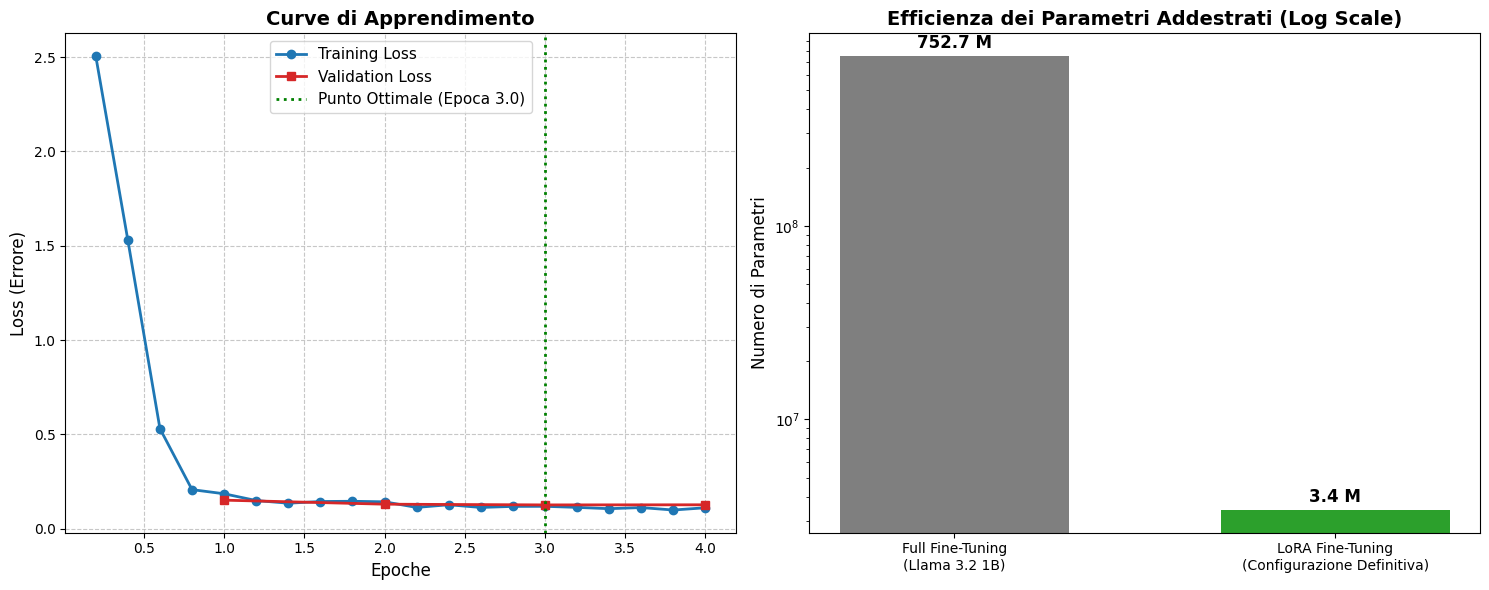


💡 Efficienza architetturale: Stiamo addestrando solo lo 0.453% dei parametri totali del modello.


In [15]:
# --- NUOVA CELLA 6b: Analisi Grafica del Training e dei Parametri ---

import matplotlib.pyplot as plt

def traccia_grafici_post_training(trainer, model):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # === GRAFICO 1: CURVE DI LOSS ===
    train_epochs, train_loss, val_epochs, val_loss = [], [], [], []
    for log in trainer.state.log_history:
        if "loss" in log and "epoch" in log:
            train_epochs.append(log["epoch"])
            train_loss.append(log["loss"])
        elif "eval_loss" in log and "epoch" in log:
            val_epochs.append(log["epoch"])
            val_loss.append(log["eval_loss"])
    
    ax1.plot(train_epochs, train_loss, label='Training Loss', color='#1f77b4', marker='o', linewidth=2)
    ax1.plot(val_epochs, val_loss, label='Validation Loss', color='#d62728', marker='s', linewidth=2)
    ax1.set_title('Curve di Apprendimento', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoche', fontsize=12)
    ax1.set_ylabel('Loss (Errore)', fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    if val_loss:
        min_val_loss = min(val_loss)
        epoca_ottimale = val_epochs[val_loss.index(min_val_loss)]
        ax1.axvline(x=epoca_ottimale, color='green', linestyle=':', linewidth=2, 
                    label=f'Punto Ottimale (Epoca {epoca_ottimale:.1f})')
    ax1.legend(fontsize=11)
    
    # === GRAFICO 2: CONFRONTO PARAMETRI (LORA vs FULL) ===
    # Cerchiamo nel modello interno al trainer (che ha i pesi LoRA applicati)
    modello_attivo = trainer.model
    trainable_params = sum(p.numel() for p in modello_attivo.parameters() if p.requires_grad)
    all_params = sum(p.numel() for p in modello_attivo.parameters())
    
    labels = ['Full Fine-Tuning\n(Llama 3.2 1B)', 'LoRA Fine-Tuning\n(Configurazione Definitiva)']
    valori = [all_params, trainable_params]
    colori = ['#7f7f7f', '#2ca02c']
    
    # Usiamo una scala logaritmica perché la differenza è nell'ordine dei miliardi vs milioni
    bars = ax2.bar(labels, valori, color=colori, width=0.6)
    ax2.set_yscale('log')
    ax2.set_title("Efficienza dei Parametri Addestrati (Log Scale)", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Numero di Parametri", fontsize=12)
    
    # Etichette in Milioni (M) o Miliardi (B) sopra le barre
    for bar, val in zip(bars, valori):
        testo = f"{val/1e9:.2f} B" if val > 1e9 else f"{val/1e6:.1f} M"
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.05, 
                 testo, ha='center', va='bottom', fontweight='bold', fontsize=12)
                 
    plt.tight_layout()
    plt.show()
    
    perc = (trainable_params / all_params) * 100
    print(f"\n💡 Efficienza architetturale: Stiamo addestrando solo lo {perc:.3f}% dei parametri totali del modello.")

# Eseguiamo la funzione
traccia_grafici_post_training(trainer, model)

### 9 Inferenza comparativa su Test Set: Baseline (Zero-Shot) vs Modello Fine-Tuned

Questa cella esegue l'inferenza su tutti i 25 esempi del test set, generando per ciascuno **due
predizioni distinte** con lo stesso identico codice di generazione (stesso prompt, stessa strategia di
decoding greedy con `do_sample=False`), per garantire un confronto assolutamente imparziale come
descritto nella Sezione 2 (Baseline):

1. **Predizione Fine-Tuned**: generata con l'adattatore LoRA attivo (comportamento di default del
   modello dopo il training).
2. **Predizione Base**: generata disabilitando temporaneamente l'adattatore tramite il context manager
   `model.disable_adapter()` di PEFT, che spegne i pesi LoRA e fa rispondere il modello con i soli
   parametri originali di `meta-llama/Llama-3.2-1B-Instruct`, senza dover ricaricare un secondo modello
   in memoria.



In [16]:
# --- CELLA 7 INFERENZA SUL TEST ---
import ast
import torch
from peft import PeftModel # Import fondamentale per gestire gli adattatori LoRA

# ==============================================================================
# 1. CONTROLLO E CARICAMENTO DELL'ADATTATORE LORA
# ==============================================================================
try:
    # Se il modello ha già i metodi PEFT, non fa nulla
    model.disable_adapter() 

except AttributeError:

    # Se è il modello base, carichiamo i pesi che hai appena allenato
    print(f"Caricamento dell'adattatore LoRA da {OUTPUT_DIR}...")
    model = trainer.model

# ==============================================================================
# 2. PREPARAZIONE DEL DATASET DI TEST
# ==============================================================================
test_cases = []
# Estraiamo comodamente i ruoli (system, user, reference) dal dataset di test formattato.
# Il modello non ha MAI visto questi esempi durante il training, quindi è un test imparziale.
for ex in test_dataset["messages"]:
    test_cases.append({
        "system": ex[0]["content"],    # Il prompt di sistema
        "input": ex[1]["content"],     # La domanda dell'utente (la ricetta da analizzare)
        "reference": ex[2]["content"]  # La risposta "Gold" corretta (il JSON atteso)
    })

# ==============================================================================
# 3. FUNZIONE DI GENERAZIONE TESTO (INFERENZA)
# ==============================================================================
def genera_risposta(mdl, tok, system, user_input, max_new_tokens=128):
    # Struttura i messaggi secondo lo standard richiesto dal modello Chat
    messages = [{"role": "system", "content": system}, {"role": "user", "content": user_input}]
    # Applica il template di chat per creare la stringa di testo pronta per l'input
    chat_format = tok.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    # Tokenizza l'input e sposta i tensori direttamente sulla scheda video (GPU/"cuda")
    inputs = tok(chat_format, return_tensors="pt").to("cuda")
    
    # Esegue l'inferenza vera e propria
    outputs = mdl.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,  # Taglia la generazione dopo 128 token (evita loop infiniti)
        do_sample=False,  # Decoding deterministico: non genera casualmente ma sceglie sempre la parola con probabilità matematica più alta (ideale per l'estrazione dati).
    )
    
    # Decodifica l'output tagliando via i token in input (la domanda) per restituire solo la risposta generata dal modello.
    risposta = tok.decode(outputs[0][inputs["input_ids"].shape[-1]:], skip_special_tokens=True).strip()
    return risposta

# ==============================================================================
# 4. ESECUZIONE DELL'INFERENZA (CONFRONTO DIRETTO: BASE vs FINE-TUNED)
# ==============================================================================
print("Inizio Inferenza sul Test Set...")
risultati_raw = []  # Lista dove salveremo i risultati per l'analisi qualitativa

# Imposta il modello in modalità valutazione (disabilita comportamenti stocastici del training)
model.eval()

# Disabilita il calcolo dei gradienti in PyTorch per non saturare la VRAM
with torch.no_grad():
    for i, caso in enumerate(test_cases):
        
        # 1. PREDENZIONE FINE-TUNED:
        # Genera la risposta usando il modello con l'adattatore LoRA ATTIVO di default.
        pred_ft = genera_risposta(model, tokenizer, caso["system"], caso["input"])

        # 2. PREDIZIONE MODELLO BASE (ZERO-SHOT):
        # Il Context Manager di PEFT "spegne" temporaneamente i pesi dell'adattatore LoRA.
        # Dentro questo blocco 'with', il modello tornerà momentaneamente "di fabbrica" come lo avevi scaricato.
        with model.disable_adapter():
            pred_base = genera_risposta(model, tokenizer, caso["system"], caso["input"])

        # Salva l'input, il riferimento corretto e le due predizioni (Base e Fine-Tuned) per l'analisi successiva
        risultati_raw.append({
            "input": caso["input"],
            "reference": caso["reference"],
            "pred_base": pred_base,
            "pred_ft": pred_ft,
        })
        # Stampa l'avanzamento per dare un feedback visivo all'utente
        print(f"[{i+1}/{len(test_cases)}] completato")

print(f"\nInferenza completata su {len(risultati_raw)} esempi di test.")

Caricamento dell'adattatore LoRA da /kaggle/working/llama3_sottoricette...
Inizio Inferenza sul Test Set...
[1/25] completato
[2/25] completato
[3/25] completato
[4/25] completato
[5/25] completato
[6/25] completato
[7/25] completato
[8/25] completato
[9/25] completato
[10/25] completato
[11/25] completato
[12/25] completato
[13/25] completato
[14/25] completato
[15/25] completato
[16/25] completato
[17/25] completato
[18/25] completato
[19/25] completato
[20/25] completato
[21/25] completato
[22/25] completato
[23/25] completato
[24/25] completato
[25/25] completato

Inferenza completata su 25 esempi di test.


## 10. Presentazione delle Metriche di qualita e dei Risultati

Le celle seguenti calcolano ed espongono, in sequenza, l'intero paniere di metriche definito nella
Sezione 3, confrontando sistematicamente il modello Base (Zero-Shot) con il modello Fine-Tuned su tutti
i 25 esempi del Test Set isolati dalla Sezione 4 & 5:

- **Format Compliance** — validità sintattica strutturale delle risposte generate.
- **Precision, Recall e F1-Score (micro e macro)** — accuratezza dell'estrazione rispetto al Ground Truth.
- **Exact Match** — percentuale di ricette estratte senza alcun errore.
- **Tasso di Allucinazione (FDR)** — affidabilità del contenuto generato tramite fuzzy matching.
- **Metriche di Sistema** — latenza, throughput e impronta VRAM in fase di inferenza.

Ogni metrica viene prima calcolata singolarmente, con relativa tabella di confronto Base vs Fine-Tuned e
delta netto, per poi confluire in una tabella riepilogativa complessiva (Sezione 8) che raccoglie tutti i
risultati in un unico riferimento. A seguire, la Sezione 9 approfondisce l'analisi qualitativa,
esaminando nel dettaglio i casi di successo e di fallimento più rappresentativi individuati automaticamente
tra i 25 esempi di test.

In [17]:
# --- CELLA 8a: Analisi qualitativa - Modello Base ---
import pandas as pd
pd.set_option("display.max_colwidth", None)

df_base = pd.DataFrame([
    {
        "Input": r["input"],
        "Riferimento (Gold)": r["reference"],
        "Predizione Base": r["pred_base"]
    }
    for r in risultati_raw
])

print("==========================================================")
print("   ANALISI QUALITATIVA: INFERENZA MODELLO BASE")
print("==========================================================")
display(df_base)

   ANALISI QUALITATIVA: INFERENZA MODELLO BASE


,Input,Riferimento (Gold),Predizione Base
0,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nLasagne vegetariane\nIngredienti: pasta all'uovo, zucchine, melanzane, peperoni rossi, latte intero, burro, farina 00.\nProcedimento: Preparate la besciamella addensandola sul fuoco. Grigliate le verdure. Alternate strati in teglia con la pasta pronta.","Analisi: Il testo menziona Pasta per lasagne, Besciamella, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta per lasagne"", ""Besciamella""]","Analisi:\n\n* **Ingredienti**: la ricetta menziona la pasta all'uovo, zucchine, melanzane, peperoni rossi, latte intero e burro. Questi ingredienti sono tutti sottoricette.\n* **Procedimento**: la ricetta menziona la preparazione della besciamella, che è una sottoricetta autonoma. La besciamella è una miscela di burro e farina di mais, cotto a fuoco, che non è solo una miscela di ingredienti, ma anche una preparazione che"
1,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nTorta mousse al cioccolato fondente\nIngredienti: pasta biscotto, mousse al cioccolato, cacao amaro.\nProcedimento: Preparate una base di pasta biscotto. Montate la mousse al cioccolato sciogliendo cioccolato fondente e unendolo a panna montata, e versatela sopra la base. Fate rassodare in frigorifero e spolverate di cacao.","Analisi: Il testo menziona Pasta biscotto, Mousse al cioccolato, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta biscotto"", ""Mousse al cioccolato""]","Analisi:\n\n* **Ingredienti**: la ricetta richiede una base di pasta biscotto, mousse al cioccolato, cacao amaro.\n* **Procedimento**: la preparazione della base di pasta biscotto, la cottura della mousse al cioccolato e la montatura della mousse al cioccolato sulla base, e la spolveratura con cacao amaro.\n\nSottoricette presenti:\n\n* **Pasta biscotto**: la ricetta richiede una base di pasta biscotto, che è un ingrediente autonome.\n*"
2,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nCassata siciliana\nIngredienti: farina 00, uova, zucchero semolato, ricotta di pecora, gocce di cioccolato fondente, frutta candita mista. \nProcedimento: Preparate e cuocete il pan di spagna. Lavorate la ricotta con lo zucchero. Foderate uno stampo con fette di torta soffice e farcite con la crema di ricotta.","Analisi: Il testo menziona Pan di spagna, che sono preparazioni autonome da estrarre.\nJSON: [""Pan di spagna""]","Basandomi sul test della sottoricetta, identifico le sottoricette presenti nella ricetta:\n\n* **Biscotto**: è un ingrediente che supera il test della trasformazione, poiché la farina 00 non viene cotturata, ma solo lavorata.\n* **Crema di ricotta**: è un ingrediente che supera il test della trasformazione, poiché la ricotta viene lavorata con lo zucchero, ma non cotturata.\n* **Cocca**: è un ingrediente che supera il test"
3,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nMousse al cioccolato\nIngredienti: cioccolato fondente, uova, zucchero, panna. \nProcedimento: Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fuso e mescolate delicatamente.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],"Analisi:\n\n* **Ingredienti:** cioccolato fondente, uova, zucchero, panna.\n* **Procedimento:** Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fuso e mescolate delicatamente.\n\nSottoricette presenti:\n\n* **Sciogliere il cioccolato**: è un procedimento che non supera il test della trasformazione, poiché il cioccolato non viene cotto.\n* **"
4,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nTartare di manzo\nIngredienti: manzo, capperi, senape, limone, tuorlo d'uovo. \nProcedimento: Tritate la carne al coltello. Condite a crudo e adagiatevi un tuorlo crudo.",Analisi: Il procedimento non menziona preparazioni autonome compl

In [18]:
# --- CELLA 8b: Analisi qualitativa - Modello Fine-Tuned ---
df_ft = pd.DataFrame([
    {
        "Input": r["input"],
        "Riferimento (Gold)": r["reference"],
        "Predizione Fine-Tuned": r["pred_ft"]
    }
    for r in risultati_raw
])

print("\n==========================================================")
print("   ANALISI QUALITATIVA: INFERENZA MODELLO FINE-TUNED")
print("==========================================================")
display(df_ft)


   ANALISI QUALITATIVA: INFERENZA MODELLO FINE-TUNED


,Input,Riferimento (Gold),Predizione Fine-Tuned
0,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nLasagne vegetariane\nIngredienti: pasta all'uovo, zucchine, melanzane, peperoni rossi, latte intero, burro, farina 00.\nProcedimento: Preparate la besciamella addensandola sul fuoco. Grigliate le verdure. Alternate strati in teglia con la pasta pronta.","Analisi: Il testo menziona Pasta per lasagne, Besciamella, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta per lasagne"", ""Besciamella""]","Analisi: Il testo menziona Besciamella, che sono preparazioni autonome da estrarre.\nJSON: [""Besciamella""]"
1,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nTorta mousse al cioccolato fondente\nIngredienti: pasta biscotto, mousse al cioccolato, cacao amaro.\nProcedimento: Preparate una base di pasta biscotto. Montate la mousse al cioccolato sciogliendo cioccolato fondente e unendolo a panna montata, e versatela sopra la base. Fate rassodare in frigorifero e spolverate di cacao.","Analisi: Il testo menziona Pasta biscotto, Mousse al cioccolato, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta biscotto"", ""Mousse al cioccolato""]","Analisi: Il testo menziona Pasta biscotto, Mousse al cioccolato, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta biscotto"", ""Mousse al cioccolato""]"
2,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nCassata siciliana\nIngredienti: farina 00, uova, zucchero semolato, ricotta di pecora, gocce di cioccolato fondente, frutta candita mista. \nProcedimento: Preparate e cuocete il pan di spagna. Lavorate la ricotta con lo zucchero. Foderate uno stampo con fette di torta soffice e farcite con la crema di ricotta.","Analisi: Il testo menziona Pan di spagna, che sono preparazioni autonome da estrarre.\nJSON: [""Pan di spagna""]","Analisi: Il testo menziona Pan di spagna, crema di ricotta, che sono preparazioni autonome da estrarre.\nJSON: [""Pan di spagna"", ""crema di ricotta""]"
3,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nMousse al cioccolato\nIngredienti: cioccolato fondente, uova, zucchero, panna. \nProcedimento: Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fuso e mescolate delicatamente.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],"Analisi: Il testo menziona cioccolato, uova e panna, che sono preparazioni autonome da estrarre in questa ricetta.\nJSON: [""cioccolato"", ""uova"", ""panna""]"
4,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nTartare di manzo\nIngredienti: manzo, capperi, senape, limone, tuorlo d'uovo. \nProcedimento: Tritate la carne al coltello. Condite a crudo e adagiatevi un tuorlo crudo.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: []
5,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nPurè di patate\nIngredienti: patate, burro, latte, noce moscata, sale. \nProcedimento: Lessate le patate. Schiacciatele e mescolatele con burro e latte bollente fino a ottenere un purè cremoso.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: []
6,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nQuiche ai porri e formaggio\nIngredienti: farina, burro, acqua, porri, panna, uova, formaggio. \nProcedimento: Impastate la brisée con farina, burro e acqua e fatela riposare in frigorifero. Stufate i porri in padella. Foderate uno stampo con la brisée, versate porri, panna, uova sbattute e formaggio, e cuocete in forno.","Analisi: Il testo menziona la preparazione del

In [19]:
# --- CELLA 8c: Funzione di calcolo metriche per singolo esempio ---

import re
import json

def estrai_json_pulito(testo_modello):
    """
    Estrae l'array JSON dalla risposta del modello, sia in formato CoT
    ("Analisi: ...\nJSON: [...]") sia in formato semplice.
    Ritorna:
      - list  -> parsing riuscito (anche lista vuota [] se il modello ha risposto correttamente "nessuna sottoricetta")
      - None  -> parsing fallito (nessun array valido individuato)
    """
    # 1. Cerca il tag "JSON:" seguito da un array (caso atteso, sia per predizioni che per reference)
    match = re.search(r'JSON:\s*(\[.*?\])', testo_modello, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(1))
        except Exception:
            pass  # tag trovato ma contenuto non parsabile -> proviamo il fallback

    # 2. Fallback: cerca il primo array [...] ovunque nel testo (non greedy, si ferma alla prima ']')
    match_fallback = re.search(r'\[.*?\]', testo_modello, re.DOTALL)
    if match_fallback:
        try:
            return json.loads(match_fallback.group(0))
        except Exception:
            return None

    # 3. Nessun array individuato: parsing fallito
    return None


def calcola_metriche_esempio(y_true_str, y_pred_str):
    """Calcola tp/fp/fn e le metriche per un singolo esempio (CoT compatible)."""

    # 1. Estrai la predizione
    pred_estratta = estrai_json_pulito(y_pred_str)
    formato_corretto = pred_estratta is not None   # distingue "parsing fallito" da "array vuoto corretto"
    pred_list = pred_estratta if pred_estratta is not None else []

    # 2. FIX: estrai il riferimento con lo STESSO estrattore, perché ora anche il reference
    #    è nel formato "Analisi: ...\nJSON: [...]" e non un array puro
    true_estratta = estrai_json_pulito(y_true_str)
    true_list = true_estratta if true_estratta is not None else []

    # Normalizzazione per confronto (minuscolo, senza spazi)
    true_set = set(str(x).lower().strip() for x in true_list)
    pred_set = set(str(x).lower().strip() for x in pred_list)

    # Calcolo TP, FP, FN
    tp = len(true_set & pred_set)
    fp = len(pred_set - true_set)
    fn = len(true_set - pred_set)

    # Calcolo metriche (caso limite: reference vuoto e predizione vuota -> match perfetto)
    if tp + fp == 0 and tp + fn == 0:
        precision_i = recall_i = f1_i = 1.0
    else:
        precision_i = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_i = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1_i = 2 * precision_i * recall_i / (precision_i + recall_i) if (precision_i + recall_i) > 0 else 0.0

    return {
        "tp": tp, "fp": fp, "fn": fn,
        "formato_corretto": formato_corretto,
        "precision": precision_i, "recall": recall_i, "f1": f1_i,
    }

metriche_base = [calcola_metriche_esempio(r["reference"], r["pred_base"]) for r in risultati_raw]
metriche_ft   = [calcola_metriche_esempio(r["reference"], r["pred_ft"])   for r in risultati_raw]

def aggrega(metriche):
    return (sum(m["tp"] for m in metriche),
            sum(m["fp"] for m in metriche),
            sum(m["fn"] for m in metriche))

tp_b, fp_b, fn_b = aggrega(metriche_base)
tp_f, fp_f, fn_f = aggrega(metriche_ft)

In [20]:
# --- CELLA 8d: Metrica 1 - Format Compliance ---

# % di risposte che sono un array Python/JSON validamente parsabile (ast.literal_eval)
# --- CALCOLO FORMAT COMPLIANCE (Validità Strutturale del JSON) ---

# Calcolo delle percentuali
comp_base = (sum(m["formato_corretto"] for m in metriche_base) / len(metriche_base)) * 100
comp_ft   = (sum(m["formato_corretto"] for m in metriche_ft) / len(metriche_ft)) * 100

# Calcolo del miglioramento netto
delta_comp = comp_ft - comp_base

# Stampa formattata da report
print("\n" + "=" * 55)
print(" 🛠️  ANALISI FORMAT COMPLIANCE (JSON VALIDO)")
print("=" * 55)
print(f"{'Modello Base':<35} {comp_base:>8.1f}%")
print(f"{'Modello Fine-Tuned':<35} {comp_ft:>8.1f}%")
print("-" * 55)
print(f"{'Miglioramento Architetturale':<35} {delta_comp:>+8.1f}%")
print("=" * 55)

if comp_ft == 100.0:
    print("\n✅ RISULTATO PERFETTO: Il modello Fine-Tuned ha raggiunto")
    print("   il 100% di affidabilità strutturale. Pronto per l'integrazione!")



 🛠️  ANALISI FORMAT COMPLIANCE (JSON VALIDO)
Modello Base                            16.0%
Modello Fine-Tuned                     100.0%
-------------------------------------------------------
Miglioramento Architetturale           +84.0%

✅ RISULTATO PERFETTO: Il modello Fine-Tuned ha raggiunto
   il 100% di affidabilità strutturale. Pronto per l'integrazione!


In [21]:
# --- CELLA 8e: Metrica 2 - Precision (micro, aggregata su tutto il test set) ---

# 1. Calcolo della Precision
prec_base = tp_b / (tp_b + fp_b) if (tp_b + fp_b) > 0 else 0.0
prec_ft   = tp_f / (tp_f + fp_f) if (tp_f + fp_f) > 0 else 0.0

# 2. Miglioramento
delta_prec = prec_ft - prec_base

# 3. Report
print("\n" + "=" * 60)
print(" 🛠️ CONFRONTO DELLA PRECISION")
print("=" * 60)
print(f"{'Modello':<20}{'Precision':>15}")
print("-" * 60)
print(f"{'Modello Base':<20}{prec_base:>15.3f}")
print(f"{'Modello Fine-Tuned':<20}{prec_ft:>15.3f}")
print("-" * 60)
print(f"{'Miglioramento':<20}{delta_prec:+15.3f}")
print("=" * 60)


 🛠️ CONFRONTO DELLA PRECISION
Modello                   Precision
------------------------------------------------------------
Modello Base                  0.273
Modello Fine-Tuned            0.696
------------------------------------------------------------
Miglioramento                +0.423


In [23]:
# --- CELLA 8f: Metrica 3 - Recall (micro, aggregata su tutto il test set) ---
# 1. Calcolo della Recall
rec_base = tp_b / (tp_b + fn_b) if (tp_b + fn_b) > 0 else 0.0
rec_ft   = tp_f / (tp_f + fn_f) if (tp_f + fn_f) > 0 else 0.0

# 2. Miglioramento (delta)
delta_rec = rec_ft - rec_base

# 3. Report
print("\n" + "=" * 60)
print("   🛠️ CONFRONTO DELLA RECALL")
print("=" * 60)
print(f"{'Modello':<20}{'Recall':>15}")
print("-" * 60)
print(f"{'Modello Base':<20}{rec_base:>15.3f}")
print(f"{'Modello Fine-Tuned':<20}{rec_ft:>15.3f}")
print("-" * 60)
print(f"{'Miglioramento':<20}{delta_rec:+15.3f}")
print("=" * 60)



   🛠️ CONFRONTO DELLA RECALL
Modello                      Recall
------------------------------------------------------------
Modello Base                  0.136
Modello Fine-Tuned            0.727
------------------------------------------------------------
Miglioramento                +0.591


In [24]:
# --- CELLA 8g: Metrica 4 - F1 Score (micro E macro, correttamente etichettate) ---
# ==========================
# Calcolo F1
# ==========================

# Micro F1
f1_micro_base = (
    2 * prec_base * rec_base / (prec_base + rec_base)
    if (prec_base + rec_base) > 0 else 0.0
)

f1_micro_ft = (
    2 * prec_ft * rec_ft / (prec_ft + rec_ft)
    if (prec_ft + rec_ft) > 0 else 0.0
)

# Macro F1
f1_macro_base = sum(m["f1"] for m in metriche_base) / len(metriche_base)
f1_macro_ft   = sum(m["f1"] for m in metriche_ft) / len(metriche_ft)

# Miglioramenti
delta_micro = f1_micro_ft - f1_micro_base
delta_macro = f1_macro_ft - f1_macro_base

# ==========================
# Report
# ==========================

print("\n" + "=" * 65)
print("    🛠️  CONFRONTO F1 SCORE")
print("=" * 65)
print(f"{'Metrica':<20}{'Base':>12}{'Fine-Tuned':>15}{'Delta':>13}")
print("-" * 65)
print(f"{'F1 Micro':<20}{f1_micro_base:>12.3f}{f1_micro_ft:>15.3f}{delta_micro:>+13.3f}")
print(f"{'F1 Macro':<20}{f1_macro_base:>12.3f}{f1_macro_ft:>15.3f}{delta_macro:>+13.3f}")
print("=" * 65)


    🛠️  CONFRONTO F1 SCORE
Metrica                     Base     Fine-Tuned        Delta
-----------------------------------------------------------------
F1 Micro                   0.182          0.711       +0.529
F1 Macro                   0.332          0.787       +0.455


### 11 Analisi qualitativa dell'inefficienza del modello Base (Zero-Shot)

La baseline del modello base  si è dimostrata totalmente inadatta all'uso in produzione e
rivela tre pattern di fallimento distinti e ricorrenti:

**1. Verbosità incontrollata e troncamento prematuro.** Il modello non rispetta mai il formato sintetico
in due passagg richiesto dal system prompt, producendo invecelunghe analisi discorsive in stile markdown. 
 Con `max_new_tokens=128`, questo porta sistematicamente la
generazione a interrompersi a metà frase prima di raggiungere un output strutturato 

**2. Confusione sistematica tra ingredienti grezzi e sottoricette.** Il modello fatica ad applicare il
"Test della Sottoricetta" descritto nel prompt, tendendo a classificare come sottoricetta qualunque
sostantivo presente nella lista ingredienti

**3. Ragionamento interno incoerente o auto-contraddittorio.** In diversi casi il modello formula un
criterio nel testo e poi lo applica in modo contraddittorio nella stessa risposta. 

### 12. Analisi qualitativa modello fine tuned

il modello ha interiorizzato a pieno la semantica del task riuscendo sempre a restituire un formato coretto,eliminando la verbosita incontrollata e svillupando un ragionamento
coerente che lo rende nettamente migliore al modello base


In [25]:
# --- CELLA 8h: Analisi qualitativa - Input, Riferimento (Gold), Predizione Base e Fine-Tuned ---
import pandas as pd
pd.set_option("display.max_colwidth", None)

df_qualitativo = pd.DataFrame([
    {
        "Input": r["input"],
        "Riferimento (Gold)": r["reference"],
        "Predizione Base": r["pred_base"],
        "Predizione Fine-Tuned": r["pred_ft"],
        "Formato": metriche_ft[i]["formato_corretto"],
        "Valore FT F1": round(metriche_ft[i]["f1"], 2),
    }
    for i, r in enumerate(risultati_raw)
])

df_qualitativo

,Input,Riferimento (Gold),Predizione Base,Predizione Fine-Tuned,Formato,Valore FT F1
0,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nLasagne vegetariane\nIngredienti: pasta all'uovo, zucchine, melanzane, peperoni rossi, latte intero, burro, farina 00.\nProcedimento: Preparate la besciamella addensandola sul fuoco. Grigliate le verdure. Alternate strati in teglia con la pasta pronta.","Analisi: Il testo menziona Pasta per lasagne, Besciamella, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta per lasagne"", ""Besciamella""]","Analisi:\n\n* **Ingredienti**: la ricetta menziona la pasta all'uovo, zucchine, melanzane, peperoni rossi, latte intero e burro. Questi ingredienti sono tutti sottoricette.\n* **Procedimento**: la ricetta menziona la preparazione della besciamella, che è una sottoricetta autonoma. La besciamella è una miscela di burro e farina di mais, cotto a fuoco, che non è solo una miscela di ingredienti, ma anche una preparazione che","Analisi: Il testo menziona Besciamella, che sono preparazioni autonome da estrarre.\nJSON: [""Besciamella""]",True,0.67
1,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nTorta mousse al cioccolato fondente\nIngredienti: pasta biscotto, mousse al cioccolato, cacao amaro.\nProcedimento: Preparate una base di pasta biscotto. Montate la mousse al cioccolato sciogliendo cioccolato fondente e unendolo a panna montata, e versatela sopra la base. Fate rassodare in frigorifero e spolverate di cacao.","Analisi: Il testo menziona Pasta biscotto, Mousse al cioccolato, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta biscotto"", ""Mousse al cioccolato""]","Analisi:\n\n* **Ingredienti**: la ricetta richiede una base di pasta biscotto, mousse al cioccolato, cacao amaro.\n* **Procedimento**: la preparazione della base di pasta biscotto, la cottura della mousse al cioccolato e la montatura della mousse al cioccolato sulla base, e la spolveratura con cacao amaro.\n\nSottoricette presenti:\n\n* **Pasta biscotto**: la ricetta richiede una base di pasta biscotto, che è un ingrediente autonome.\n*","Analisi: Il testo menziona Pasta biscotto, Mousse al cioccolato, che sono preparazioni autonome da estrarre.\nJSON: [""Pasta biscotto"", ""Mousse al cioccolato""]",True,1.00
2,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nCassata siciliana\nIngredienti: farina 00, uova, zucchero semolato, ricotta di pecora, gocce di cioccolato fondente, frutta candita mista. \nProcedimento: Preparate e cuocete il pan di spagna. Lavorate la ricotta con lo zucchero. Foderate uno stampo con fette di torta soffice e farcite con la crema di ricotta.","Analisi: Il testo menziona Pan di spagna, che sono preparazioni autonome da estrarre.\nJSON: [""Pan di spagna""]","Basandomi sul test della sottoricetta, identifico le sottoricette presenti nella ricetta:\n\n* **Biscotto**: è un ingrediente che supera il test della trasformazione, poiché la farina 00 non viene cotturata, ma solo lavorata.\n* **Crema di ricotta**: è un ingrediente che supera il test della trasformazione, poiché la ricotta viene lavorata con lo zucchero, ma non cotturata.\n* **Cocca**: è un ingrediente che supera il test","Analisi: Il testo menziona Pan di spagna, crema di ricotta, che sono preparazioni autonome da estrarre.\nJSON: [""Pan di spagna"", ""crema di ricotta""]",True,0.67
3,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nMousse al cioccolato\nIngredienti: cioccolato fondente, uova, zucchero, panna. \nProcedimento: Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fuso e mescolate delicatamente.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],"Analisi:\n\n* **Ingredienti:** cioccolato fondente, uova, zucchero, panna.\n* **Procedimento:** Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fu

**Analisi dei successi (Modello Fine-Tuned):** il modello ha interiorizzato a pieno la semantica del
task. Su ricette insidiose come i *"Biscotti da tè"*, la baseline falliva non estraendo nulla, mentre il
modello Fine-Tuned estrae correttamente `["Pasta frolla"]`. Negli Hard Negative, come la *"Tartare di
manzo"* o la *"Salsa olandese"*, il modello Fine-Tuned restituisce coerentemente `[]`, identificando che
le operazioni descritte (mescolatura a crudo, montatura senza cottura) non soddisfano la vera definizione
strutturale di "sottoricetta".



### 13. Analisi dei Failure Case (Cella 7i)

Su 25 esempi di test, si contano **8 casi di fallimento** (F1 < 1.0), di cui 4 con F1 = 0.00 e 4 con F1
parziale (0.60–0.67). Gli errori si distribuiscono in tre categorie ricorrenti:

- **Omissione della seconda sottoricetta**: nella maggior parte dei fallimenti parziali, il modello
  estrae correttamente solo la prima preparazione esplicitamente nominata nel testo, omettendo una
  seconda sottoricetta citata più avanti nel procedimento.
- **Denominazione diversa da quella attesa**: in alcuni casi il modello individua la sottoricetta
  giusta ma la nomina in modo diverso dal gold (o la scompone erroneamente in più voci), fallendo il
  match esatto nonostante la comprensione semantica sia corretta.
- **Falsi positivi/negativi isolati su casi limite**: un numero ridotto di errori riguarda ingredienti
  al confine della definizione di "sottoricetta" (lavorati ma non cotti/emulsionati) o un singolo caso di
  regressione completa al comportamento del modello Base.

Questa distribuzione conferma, sugli 8 casi di fallimento reali, i pattern già discussi qualitativamente
nella Sezione 12: gli errori residui del modello Fine-Tuned sono prevalentemente di natura semantica e di
confine (recall incompleta, confusione occasionale tra entità e denominazioni), non strutturali come nel
caso del modello Base.

In [26]:
# --- CELLA 8i: Failure cases (per la sezione "Analysis of results" richiesta dalle specifiche) ---
# Le specifiche del progetto richiedono di identificare almeno tre casi di fallimento: qui li isoliamo automaticamente.
df_fallimenti = df_qualitativo[df_qualitativo["Valore FT F1"] < 1.0].sort_values("Valore FT F1")
print(f"Trovati {len(df_fallimenti)} casi di fallimento su {len(df_qualitativo)} test totali (F1 dell'esempio < 1.0)")
df_fallimenti

Trovati 8 casi di fallimento su 25 test totali (F1 dell'esempio < 1.0)


,Input,Riferimento (Gold),Predizione Base,Predizione Fine-Tuned,Formato,Valore FT F1
6,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nQuiche ai porri e formaggio\nIngredienti: farina, burro, acqua, porri, panna, uova, formaggio. \nProcedimento: Impastate la brisée con farina, burro e acqua e fatela riposare in frigorifero. Stufate i porri in padella. Foderate uno stampo con la brisée, versate porri, panna, uova sbattute e formaggio, e cuocete in forno.","Analisi: Il testo menziona la preparazione della pasta brisée, impasto a freddo strutturato che supera il test della trasformazione.\nJSON: [""Pasta brisée""]","Basandomi sul test della sottoricetta, identifico le sottoricette presenti nella ricetta:\n\n* **Brisée**: è un impasto lievitato, quindi supera il test della trasformazione.\n* **Porri**: sono già pronti e non superano il test della trasformazione.\n* **Panna**: è un prodotto pronto, quindi supera il test della trasformazione.\n* **Uova**: sono già sbattute e non superano il test della trasformazione.\n* **Formaggio**: è un prodotto pronto,","Analisi: Il testo menziona Brisée, che sono preparazioni autonome da estrarre in due passaggi: Impastate e Foderate.\nJSON: [""Brisée"", ""Foderate""]",True,0.00
3,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nMousse al cioccolato\nIngredienti: cioccolato fondente, uova, zucchero, panna. \nProcedimento: Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fuso e mescolate delicatamente.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],"Analisi:\n\n* **Ingredienti:** cioccolato fondente, uova, zucchero, panna.\n* **Procedimento:** Sciogliete il cioccolato. Montate a crudo gli albumi con zucchero e la panna. Incorporate il cioccolato fuso e mescolate delicatamente.\n\nSottoricette presenti:\n\n* **Sciogliere il cioccolato**: è un procedimento che non supera il test della trasformazione, poiché il cioccolato non viene cotto.\n* **","Analisi: Il testo menziona cioccolato, uova e panna, che sono preparazioni autonome da estrarre in questa ricetta.\nJSON: [""cioccolato"", ""uova"", ""panna""]",True,0.00
18,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nTempura di verdure\nIngredienti: farina, acqua ghiacciata, uovo, zucchine, carote, olio per friggere. \nProcedimento: Tagliate le verdure a listarelle. Preparate la pastella per tempura sbattendo uovo, farina e acqua ghiacciata fino a ottenere un composto leggero. Passate le verdure nella pastella e friggetele.","Analisi: Il testo menziona la preparazione della pastella per tempura, un impasto strutturato che supera il test della trasformazione.\nJSON: [""Pastella""]","Non ci sono sottoricette presenti nella ricetta. La pastella preparata è solo una base per la tempura, ma non contiene ingredienti che superano il test della trasformazione.","Analisi: Il testo menziona la preparazione della pastella per tempura, che supera il test della trasformazione e è una ricetta autonoma.\nJSON: [""Pastella per tempura""]",True,0.00
24,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nInsalata russa con tonno\nIngredienti: patate, carote, piselli, uova,tonno, maionese.\nProcedimento: Lessate le patate, le carote e le uova. Tagliatele a cubetti e mescolatele con i piselli, il tonno e la maionese .","Analisi: Il testo menziona Maionese, che supera il test della trasformazione in quanto è un'emulsione cotta e strutturata.\nJSON: [""Maionese""]","Non ci sono sottoricette presenti nella ricetta. \n\nLa ricetta menziona solo ingredienti e procedimenti di preparazione, ma non specifica l'impasto o la trasformazione che crea l'identità autonoma.",Analisi: Il procedimento non menziona preparazioni autonome complesse che richiedono cottura o emulsione.\nJSON: [],True,0.00
0,"Analizza questa ricetta e identifica le sottoricette presenti:\n\nLasagne vegetariane\nIngred

In [30]:
# ---  CELLA 8l: ---   Exact Match e Tasso di Allucinazione (FDR) ---
import difflib

def calcola_metriche_avanzate(y_true_str, y_pred_str, soglia_fuzzy=0.8):
    pred_estratta = estrai_json_pulito(y_pred_str)
    true_estratta = estrai_json_pulito(y_true_str)

    parsing_fallito = pred_estratta is None   # distingue "non ha risposto nulla di valido" da "ha risposto []"
    pred_list = pred_estratta if pred_estratta is not None else []
    true_list = true_estratta if true_estratta is not None else []

    true_str_list = [str(x).lower().strip() for x in true_list]
    pred_str_list = [str(x).lower().strip() for x in pred_list]

    exact_match = 1 if (not parsing_fallito and sorted(true_str_list) == sorted(pred_str_list)) else 0

    tp_fuzzy, fp_fuzzy = 0, 0
    for pred_item in pred_str_list:
        best_ratio = max(
            (difflib.SequenceMatcher(None, pred_item, true_item).ratio() for true_item in true_str_list),
            default=0
        )
        if best_ratio >= soglia_fuzzy:
            tp_fuzzy += 1
        else:
            fp_fuzzy += 1


    # sui totali del test set, come  per precision/recall/F1.
    # In questo modo un esempio con parsing fallito o zero predizioni non
    # viene silenziosamente contato come "zero allucinazioni".
    return {
        "exact_match": exact_match,
        "tp_fuzzy": tp_fuzzy,
        "fp_fuzzy": fp_fuzzy,
        "parsing_fallito": parsing_fallito,
    }

def aggrega_avanzate(risultati, chiave_pred):
    metriche = [calcola_metriche_avanzate(r["reference"], r[chiave_pred]) for r in risultati]
    em = sum(m["exact_match"] for m in metriche) / len(metriche)
    tp_tot = sum(m["tp_fuzzy"] for m in metriche)
    fp_tot = sum(m["fp_fuzzy"] for m in metriche)
    fdr = fp_tot / (fp_tot + tp_tot) if (fp_tot + tp_tot) > 0 else 0.0
    parsing_falliti = sum(m["parsing_fallito"] for m in metriche)
    return em, fdr, parsing_falliti

em_totale_base, fdr_medio_base, fail_base = aggrega_avanzate(risultati_raw, "pred_base")
em_totale_ft, fdr_medio_ft, fail_ft = aggrega_avanzate(risultati_raw, "pred_ft")

print("=" * 60)
print(" CONFRONTO QUALITÀ DEL DATO: BASE vs FINE-TUNED")
print("=" * 60)
print(" ❌ MODELLO BASE (Zero-Shot)")
print(f" Exact Match Ratio (Zero Errori) : {em_totale_base*100:.1f}%")
print(f" Tasso Allucinazione (FDR)       : {fdr_medio_base*100:.1f}%  "
      f"(su {len(risultati_raw)-fail_base} risposte parsabili; {fail_base} non hanno prodotto JSON valido)")
print("-" * 60)
print(" ✅ MODELLO FINE-TUNED (LoRA)")
print(f" Exact Match Ratio (Zero Errori) : {em_totale_ft*100:.1f}%")
print(f" Tasso Allucinazione (FDR)       : {fdr_medio_ft*100:.1f}%  "
      f"(su {len(risultati_raw)-fail_ft} risposte parsabili; {fail_ft} non hanno prodotto JSON valido)")
print("=" * 60)

delta_em = (em_totale_ft - em_totale_base) * 100
print(f"\n💡 MIGLIORAMENTO: Il fine-tuning ha aumentato le ricette perfette del +{delta_em:.1f}%")

      


 CONFRONTO QUALITÀ DEL DATO: BASE vs FINE-TUNED
 ❌ MODELLO BASE (Zero-Shot)
 Exact Match Ratio (Zero Errori) : 0.0%
 Tasso Allucinazione (FDR)       : 72.7%  (su 4 risposte parsabili; 21 non hanno prodotto JSON valido)
------------------------------------------------------------
 ✅ MODELLO FINE-TUNED (LoRA)
 Exact Match Ratio (Zero Errori) : 68.0%
 Tasso Allucinazione (FDR)       : 30.4%  (su 25 risposte parsabili; 0 non hanno prodotto JSON valido)

💡 MIGLIORAMENTO: Il fine-tuning ha aumentato le ricette perfette del +68.0%


### 14. Metriche di Sistema (Latenza, Throughput, VRAM)
Oltre alle metriche di qualità del task, è stato eseguito uno stress-test su un sottoinsieme di 10 esempi
del test set per misurare le prestazioni del modello Fine-Tuned in condizioni di inferenza realistiche —
un aspetto rilevante per l'integrazione del componente nella pipeline agentica, dove la latenza per
chiamata incide direttamente sul tempo di risposta complessivo del sistema.

Vengono misurati:

- **Latenza media per query (ms)**: tempo medio impiegato per generare una risposta completa a una
  singola richiesta, calcolato come tempo totale diviso il numero di esempi.
- **Throughput di generazione (tokens/sec)**: velocità di generazione, calcolata come numero totale di
  token prodotti diviso il tempo totale — indipendente dalla latenza per singola richiesta, utile per
  stimare il costo di generazioni più lunghe.
- **Picco di VRAM in inferenza (MB)**: memoria GPU aggiuntiva effettivamente allocata durante la
  generazione, misurata con `torch.cuda.max_memory_allocated()` al netto della memoria già occupata dal
  modello prima dello stress-test — rilevante per valutare quante istanze del modello potrebbero
  coesistere sulla stessa GPU in un contesto di deployment.



In [31]:
# --- NUOVA CELLA 9: Metriche Hardware e di Sistema (Latenza/VRAM) ---
import time
import torch

print("Avvio stress-test per metriche di sistema...")
model.eval()
subset_test = test_cases[:10]
token_generati_totali = 0

torch.cuda.reset_peak_memory_stats()
memoria_iniziale = torch.cuda.memory_allocated()

start_time = time.time()
with torch.no_grad():
    for caso in subset_test:
        messages = [{"role": "system", "content": caso["system"]}, {"role": "user", "content": caso["input"]}]
        chat_format = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(chat_format, return_tensors="pt").to("cuda")
        
        outputs = model.generate(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_new_tokens=128,
            do_sample=False
        )
        token_generati_totali += (outputs[0].shape[-1] - inputs["input_ids"].shape[-1])
end_time = time.time()

tempo_totale = end_time - start_time
latenza_media_ms = (tempo_totale / len(subset_test)) * 1000
throughput = token_generati_totali / tempo_totale
vram_inferenza_mb = (torch.cuda.max_memory_allocated() - memoria_iniziale) / (1024 ** 2)

print(f"Latenza media per query    : {latenza_media_ms:.1f} ms")
print(f"Throughput di generazione  : {throughput:.1f} tokens/sec")
print(f"Picco VRAM in inferenza    : {vram_inferenza_mb:.1f} MB")

Avvio stress-test per metriche di sistema...
Latenza media per query    : 3762.1 ms
Throughput di generazione  : 11.3 tokens/sec
Picco VRAM in inferenza    : 382.2 MB


Risultati ottenuti: **latenza media 3762.1 ms**, **throughput 11.3 token/sec**, **picco VRAM 382.2 MB**.
La modesta impronta di memoria conferma il vantaggio dell'approccio QLoRA anche in fase di inferenza,
mentre la latenza (~3.8 secondi per ricetta) è compatibile con un utilizzo asincrono all'interno di un
nodo della pipeline agentica, ma andrebbe tenuta in considerazione se il componente venisse invocato in
un contesto che richiede risposta sincrona a bassa latenza.

### 15. Riepilogo Finale e Conclusioni

La tabella seguente raccoglie in un unico riferimento tutte le metriche discusse nelle sezioni precedenti,
confrontando modello Base (Zero-Shot) e modello Fine-Tuned sui 25 esempi del test set:

In [32]:
# ---  CELLA 10: RIEPILOGO FINALE (Statistiche + Sistema) ---

print("\n" + "=" * 76)
print(" RIEPILOGO FINALE: ESTRAZIONE SOTTORICETTE (BASE vs FINE-TUNED)")
print("=" * 76)
print(" 📊 METRICHE DI CLASSIFICAZIONE E QUALITÀ DEL DATO")
print("-" * 76)

# Intestazione allineata per 4 colonne
print(f"{'Metrica':<28}{'Base':>12}{'Fine-tuned':>16}{'Delta':>16}")
print("-" * 76)

# Blocco ML Classico
print(f"{'Format Compliance':<28}{comp_base:>11.1f}%{comp_ft:>15.1f}%{comp_ft-comp_base:>+15.1f}%")
print(f"{'Precision (micro)':<28}{prec_base:>12.3f}{prec_ft:>16.3f}{prec_ft-prec_base:>+16.3f}")
print(f"{'Recall (micro)':<28}{rec_base:>12.3f}{rec_ft:>16.3f}{rec_ft-rec_base:>+16.3f}")
print(f"{'F1 (micro)':<28}{f1_micro_base:>12.3f}{f1_micro_ft:>16.3f}{f1_micro_ft-f1_micro_base:>+16.3f}")
print(f"{'F1 (macro)':<28}{f1_macro_base:>12.3f}{f1_macro_ft:>16.3f}{f1_macro_ft-f1_macro_base:>+16.3f}")

# Blocco Qualità del Dato (Perfettamente integrato nelle 4 colonne!)
print(f"{'Exact Match (Zero Errori)':<28}{em_totale_base*100:>11.1f}%{em_totale_ft*100:>15.1f}%{(em_totale_ft-em_totale_base)*100:>+15.1f}%")
print(f"{'Tasso Allucinazione (FDR)':<28}{fdr_medio_base*100:>11.1f}%{fdr_medio_ft*100:>15.1f}%{(fdr_medio_ft-fdr_medio_base)*100:>+15.1f}%")
print("=" * 76)

# Blocco Hardware (A due colonne, allineato con precisione)
print("\n" + " ⚙️ PERFORMANCE DI SISTEMA (INFERENZA)")
print("-" * 76)
print(f"{'Latenza Media a Ricetta':<45} {latenza_media_ms:>10.1f} ms")
print(f"{'Throughput (Velocità Generazione)':<45} {throughput:>10.1f} t/s")
print(f"{'Costo VRAM Inferenza':<45} {vram_inferenza_mb:>10.1f} MB")
print("=" * 76)


 RIEPILOGO FINALE: ESTRAZIONE SOTTORICETTE (BASE vs FINE-TUNED)
 📊 METRICHE DI CLASSIFICAZIONE E QUALITÀ DEL DATO
----------------------------------------------------------------------------
Metrica                             Base      Fine-tuned           Delta
----------------------------------------------------------------------------
Format Compliance                  16.0%          100.0%          +84.0%
Precision (micro)                  0.273           0.696          +0.423
Recall (micro)                     0.136           0.727          +0.591
F1 (micro)                         0.182           0.711          +0.529
F1 (macro)                         0.332           0.787          +0.455
Exact Match (Zero Errori)           0.0%           68.0%          +68.0%
Tasso Allucinazione (FDR)          72.7%           30.4%          -42.3%

 ⚙️ PERFORMANCE DI SISTEMA (INFERENZA)
----------------------------------------------------------------------------
Latenza Media a Ricetta       

**Sintesi dei risultati:** il fine-tuning ha prodotto un miglioramento netto e coerente su ogni singola
metrica, senza eccezioni. Il salto più marcato riguarda la Format Compliance (+84 punti), a conferma che
il problema principale del modello Base non era la comprensione del task in sé, ma l'incapacità di
produrre un output strutturato affidabile — coerente con l'analisi qualitativa della Sezione 11. A valle
di questo, anche le metriche di contenuto migliorano in modo sostanziale: la Recall in particolare
quintuplica (+0.591), segno che il modello Fine-Tuned non si limita a rispettare il formato ma individua
effettivamente un numero molto maggiore di sottoricette corrette.

**Limiti residui:** il tasso di allucinazione del modello Fine-Tuned, pur dimezzato rispetto al Base,
resta al 30.4% — non trascurabile. Come discusso nella Sezione 12 e nell'analisi dei failure case
(Sezione 13), questo residuo non deriva più da un problema di formato, ma da errori semantici puntuali:
omissione di sottoricette secondarie, denominazioni diverse da quella attesa, e occasionale confusione tra
verbi procedurali ed entità. L'ipotesi di miglioramento proposta (espansione mirata del dataset sui
confini più ambigui) è coerente con questa diagnosi.

**Considerazioni di sistema:** la latenza (~3.8s per ricetta) e l'impronta VRAM contenuta (382 MB) rendono
il modello Fine-Tuned adatto all'integrazione come tool all'interno della pipeline agentica descritta
nella Sezione 1, in particolare in un contesto di esecuzione asincrona in cui il Research Node non deve
attendere una risposta sincrona istantanea.

**In conclusione**, il componente di fine-tuning soddisfa l'obiettivo definito nella Sezione 1: fornisce
 un'estrazione di sottoricette affidabile nel formato, accurata
nel contenuto nella maggioranza dei casi, e sufficientemente efficiente da poter essere invocata
ripetutamente all'interno di una pipeline agentica multi-step, con margini di miglioramento chiaramente
identificati per iterazioni future.

### 16. Ipotesi di Miglioramento Futuro

I fallimenti riscontrati non sono strutturali — il formato JSON rimane impeccabile in ogni predizione del
modello Fine-Tuned — ma legati a sfumature culinarie: confusione occasionale sui confini semantici tra
ingredienti lavorati e sottoricette vere e proprie, e denominazioni diverse da quella attesa per la stessa
preparazione (es. "Pastella" vs "Pastella per tempura").

Le direzioni di miglioramento individuate sono due:

1. **Estensione mirata del dataset**, focalizzata specificamente sui confini culinari più ambigui da
   riconoscere (es. creme lavorate ma non cotte/emulsionate) e sull'aggiunta di sinonimi e varianti
   lessicali per le stesse sottoricette, per colmare le lacune semantiche osservate.
2. **Ampliamento del train set** con un numero maggiore di esempi, per favorire un allenamento più
   robusto, accompagnato da un test set proporzionalmente più ampio per ottenere stime delle metriche
   finali più stabili e affidabili.

### 17. Merge dell'Adattatore e Salvataggio del Modello Finale

L'ultima cella del notebook fonde permanentemente i pesi dell'adattatore LoRA (Configurazione B, r=16,
lr=2e-4, checkpoint dell'epoca 3 selezionato automaticamente da `load_best_model_at_end`) con il modello
base `meta-llama/Llama-3.2-1B-Instruct`, tramite `merge_and_unload()` di PEFT. Il risultato è un unico
modello autonomo in FP16, salvato in `MERGED_DIR`, senza più dipendenza dall'adattatore separato né dalla
quantizzazione a 4-bit usata durante il training. Questo passaggio è necessario per l'integrazione del componente nella pipeline agentica descritta nella


In [27]:
# --- CELLA 11: Merge dell'Adattatore e Salvataggio Modello Completo ---
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel
import gc

print("Liberiamo la VRAM prima del Merge...")
del model
del trainer
gc.collect()
torch.cuda.empty_cache()

print("1. Caricamento del modello base in FP16 (Full Precision)...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    low_cpu_mem_usage=True,
    return_dict=True,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("2. Fusione dei pesi LoRA con il modello base (Merge & Unload)...")
# Applichiamo il tuo adattatore perfetto al modello base
model_merged = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
# Questa è la riga magica che li salda per sempre:
model_merged = model_merged.merge_and_unload() 

MERGED_DIR = "/kaggle/working/llama3_sottoricette_merged"
print(f"3. Salvataggio del modello unito e pronto all'uso in {MERGED_DIR}...")
model_merged.save_pretrained(MERGED_DIR)
tokenizer.save_pretrained(MERGED_DIR)

print("✅ Finito! Ora hai un tuo modello proprietario indipendente.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Liberiamo la VRAM prima del Merge...
1. Caricamento del modello base in FP16 (Full Precision)...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

2. Fusione dei pesi LoRA con il modello base (Merge & Unload)...
3. Salvataggio del modello unito e pronto all'uso in /kaggle/working/llama3_sottoricette_merged...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Finito! Ora hai un tuo modello proprietario indipendente.
